# 序列

**Q**: 解释术语
- 序列和集合

**Q**: 回答问题
- 序列问题分为哪两种

**Q**: 结合行文
- 从何种数据类型角度切入？
- 目前问题的定义是什么？

## 数据生成

**Q**: 生成的数据维度是？形状是？

**Q**: 该形状如何体现出序列？

In [470]:
# 引入

# 数据生成
from data_generation.square_sequences import generate_sequences
# 绘图函数
from plots.chapter8 import *

# 科学计算
import numpy as np

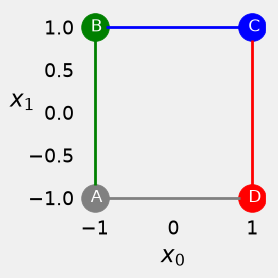

In [471]:
# 可视化: 数据形状
fig = counter_vs_clock(draw_arrows=False)

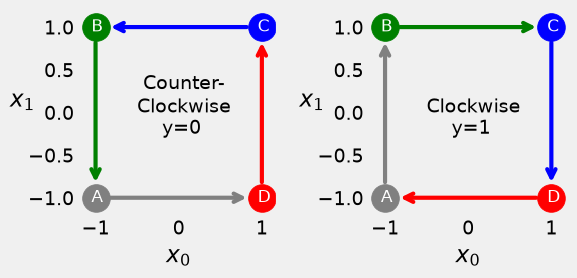

In [472]:
# 可视化: 形状与序列顺序
fig = counter_vs_clock()

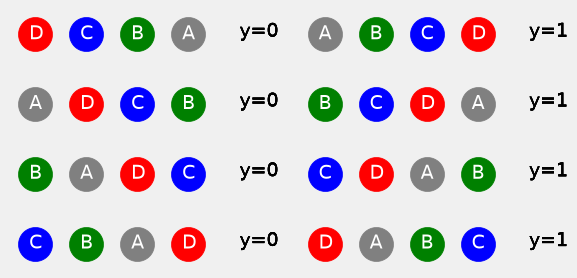

In [473]:
# 可视化: 所有可能的顺序
fig = plot_sequences()

(128, 4, 2) (128,)
[[ 1.03487506  0.96613817]
 [ 0.80546093 -0.91690943]
 [-0.82507582 -0.94988627]
 [-0.86696831  0.93424827]] 1


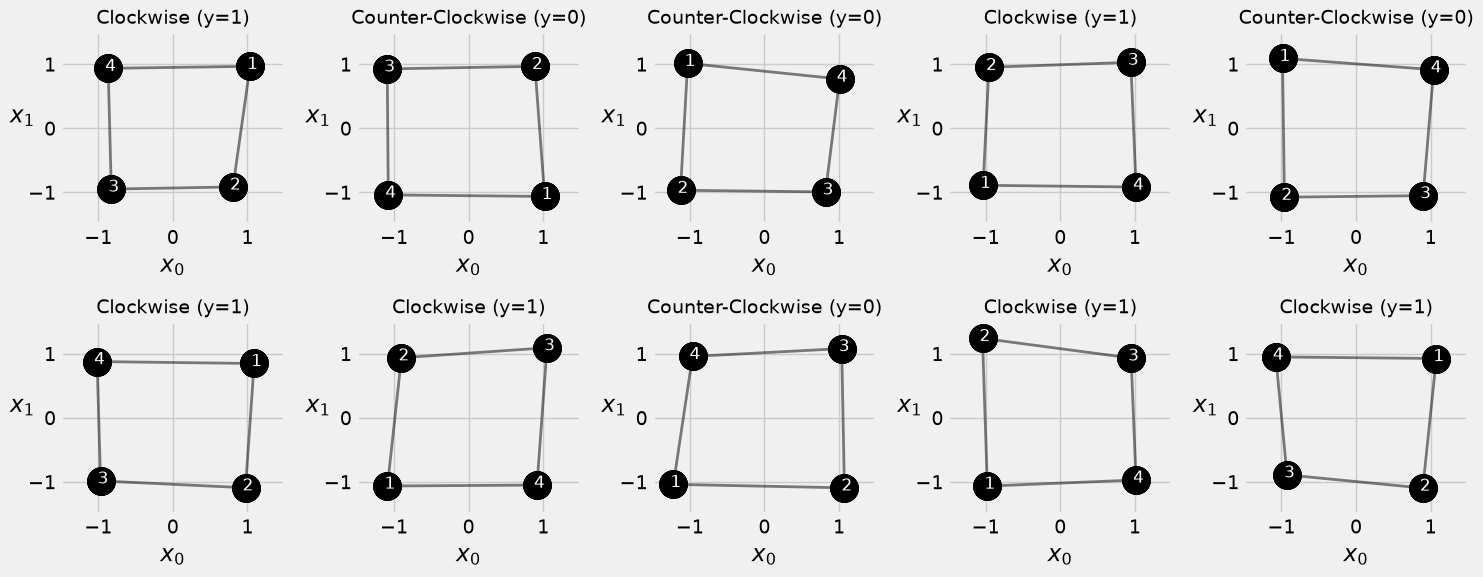

In [474]:
# 程序8-1: 生成数据
points, directions = generate_sequences(n=128, seed=13)

# 128组: 每组4点2维坐标
# 128组: 标签: 1顺时针 0 逆时针
# 1234为组内坐标顺序为绘制顺序
print(np.array(points).shape,np.array(directions).shape)

# 含有噪声的点,标签
print(points[0],directions[0]) 

# 可视化结果
fig = plot_data(points, directions)

> 目前引出了序列是有序的数据这一概念，并以二维图像数据（给两角预测剩余两角为问题）直观的作为问题

----

# 循环神经网络RNN

**Q**:解释术语:
- 隐藏状态

**Q**:回答问题:
- RNN解决的问题是什么？（从隐藏状态的角度出发）
- 作图:RNN的执行流程图是什么样的？
- 文字描述RNN的执行流程（5个步骤）
- 隐藏状态的初始状态代表了什么？
- 最终的隐藏状态代表了什么？


**Q**: 类比:
- 最终的隐藏状态和CNN的卷积块输出有什么异同？
- RNN的单元和CNN比有什么特点？

![](images/rnn2.png)

> RNN的循环意味着反复使用一个单元，上一步的输出状态加上新一步的外部数据就是下一步的输入数据

## RNN单元

**Q**: 回答问题:
- RNN单元的内部结构由什么构成？（数据操作,激活函数）
- RNN处理过程用表达式怎么表示？
- 作图: 神经元层面的RNN单元如何表示？
- 隐藏状态和输入数据在形状上有什么关系？

**Q**: 回答问题
- 为什么要使用特定的激活函数？有什么优势？

**Q**: 结合代码:
- 翻译代码步骤
- 使用`rnn_cell`要注意什么？


![](images/rnn1.png)


![](images/rnn_cell_diagram.png)




In [475]:
# 程序8-2 手动模拟RNN单元的一次计算

# 程序8-2-1: 初始化一个RNN单元(作为参数设置和对比工具)

# 程序8-2-2: 手动复现RNN单元内部的线性层

# 程序8-2-3: 初始化空序列的初始隐藏状态

# 程序8-2-4: 计算隐藏层

# 程序8-2-5: 选一个点计算输入层

# 程序8-2-6: 合并两层结果并使用激活函数

# 程序8-2-7: 测试对比结果（并可视化过程）

In [476]:
# 程序8-2-1: 如何初始化一个RNN单元

# 输入特征的维度（每个时间步的数据有2个特征，即2D坐标点）
n_features = 2
# 隐藏状态的维度（隐藏层神经元数量，设为2便于可视化）
hidden_dim = 2


torch.manual_seed(19)

# RNNCell处理单个时间步
rnn_cell = nn.RNNCell(input_size=n_features, hidden_size=hidden_dim)
rnn_state = rnn_cell.state_dict()
# 打印参数：
# weight_ih: 输入→隐藏层的权重矩阵, 形状(n_features, hidden_dim)的展平 → 实际为(hidden_dim, n_features)
# weight_hh: 隐藏层→隐藏层的权重矩阵, 形状(hidden_dim, hidden_dim)
# bias_ih: 输入→隐藏层的偏置, 形状(hidden_dim,)
# bias_hh: 隐藏层→隐藏层的偏置, 形状(hidden_dim,)
print(rnn_state)

OrderedDict([('weight_ih', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('weight_hh', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias_ih', tensor([0.4954, 0.6533])), ('bias_hh', tensor([-0.3565, -0.2904]))])


In [477]:
# 程序8-2-2: 手动复现RNN单元内部的线性层

# RNNCell内部实际就是: tanh(Linear_input(x) + Linear_hidden(h))


# Linear层：对输入x做线性变换 W_ih @ x + b_ih
linear_input = nn.Linear(n_features, hidden_dim)
# Linear层：对上一时刻隐藏状态h做线性变换 W_hh @ h + b_hh
linear_hidden = nn.Linear(hidden_dim, hidden_dim)

# 在torch.no_grad()上下文中，将RNNCell的参数复制给两个Linear层
# 这样Linear层就和RNNCell具有完全相同的权重
with torch.no_grad():
    # 将RNNCell的输入权重和偏置复制给linear_input
    linear_input.weight = nn.Parameter(rnn_state['weight_ih'])
    linear_input.bias = nn.Parameter(rnn_state['bias_ih'])
    # 将RNNCell的隐藏层权重和偏置复制给linear_hidden
    linear_hidden.weight = nn.Parameter(rnn_state['weight_hh'])
    linear_hidden.bias = nn.Parameter(rnn_state['bias_hh'])

print(linear_input.state_dict())
print(linear_hidden.state_dict())

OrderedDict([('weight', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('bias', tensor([0.4954, 0.6533]))])
OrderedDict([('weight', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias', tensor([-0.3565, -0.2904]))])


In [478]:
# 程序8-2-3: 初始化空序列的初始隐藏状态

initial_hidden = torch.zeros(1, hidden_dim)
print(initial_hidden)

tensor([[0., 0.]])


In [479]:
# 程序8-2-4: 计算隐藏层

th = linear_hidden(initial_hidden)
print(th)

tensor([[-0.3565, -0.2904]], grad_fn=<AddmmBackward0>)


In [480]:
# 程序8-2-5: 选一个点计算输入层
X = torch.as_tensor(points[0]).float()
print(X)

tx = linear_input(X[0:1])
print(tx)

tensor([[ 1.0349,  0.9661],
        [ 0.8055, -0.9169],
        [-0.8251, -0.9499],
        [-0.8670,  0.9342]])
tensor([[0.7712, 1.4310]], grad_fn=<AddmmBackward0>)


In [481]:
# 程序8-2-6: 合并两层结果并使用激活函数

adding = th + tx
print(adding)

# 激活函数: 压缩范围
print(torch.tanh(adding))

tensor([[0.4146, 1.1405]], grad_fn=<AddBackward0>)
tensor([[0.3924, 0.8146]], grad_fn=<TanhBackward0>)


tensor([[0.3924, 0.8146]], grad_fn=<TanhBackward0>)


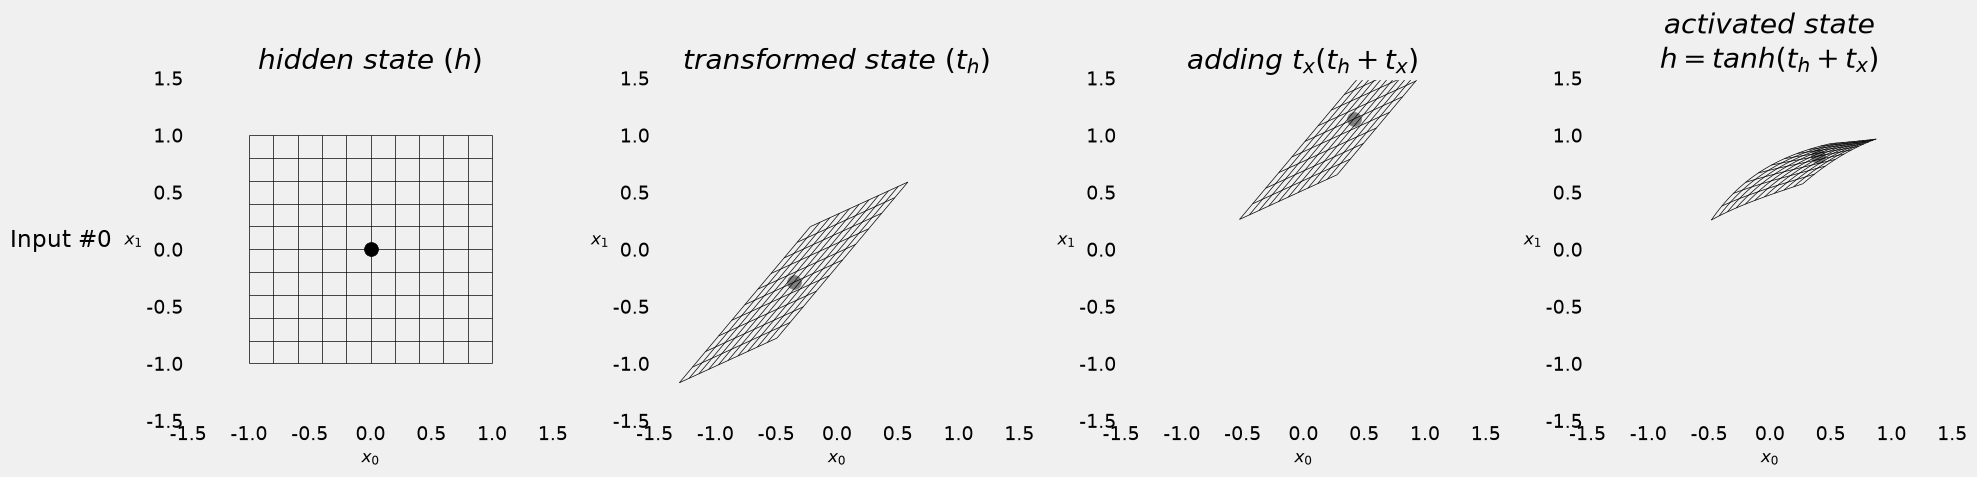

In [482]:
# 程序8-2-7: 测试对比结果并可视化过程

# 直接用RNNCell处理X[0:1]（第1个时间步的坐标点），与前面分步计算的结果对比
print(rnn_cell(X[0:1]))

# figure8函数将RNN单元内部处理过程分解为4个子图进行可视化：
# 子图1: hidden state (h)     — 当前隐藏状态在特征空间中的位置
# 子图2: transformed state    — 隐藏层线性变换结果 W_hh@h + b_hh
# 子图3: adding t_h+t_x       — 隐藏变换与输入变换相加，信息融合
# 子图4: activated state      — tanh激活后的新隐藏状态 h' = tanh(t_h+t_x)
# 注意: 子图1→子图4的变化即RNN对单个时间步的处理过程
fig = figure8(linear_hidden, linear_input, X)

In [483]:
# 程序8-3: rnn_cell的使用注意事项(实现一个序列的RNN)

print(hidden_dim)
print(X.shape[0])

# 这样做只代表4个点的第一步
# ps：不提供状态则默认初始状态
print(rnn_cell(X))

# 这才是从1-4的4步RNN
hidden = torch.zeros(1, hidden_dim)
for i in range(X.shape[0]):
    out = rnn_cell(X[i:i+1], hidden)
    print(out)
    hidden = out

2
4
tensor([[ 0.3924,  0.8146],
        [ 0.7864,  0.5266],
        [-0.0047, -0.2897],
        [-0.6817,  0.1109]], grad_fn=<TanhBackward0>)
tensor([[0.3924, 0.8146]], grad_fn=<TanhBackward0>)
tensor([[ 0.4347, -0.0481]], grad_fn=<TanhBackward0>)
tensor([[-0.1521, -0.3367]], grad_fn=<TanhBackward0>)
tensor([[-0.5297,  0.3551]], grad_fn=<TanhBackward0>)


> 上述循环可用下图表示

![](images/rnn_cell_diagram_seq.png)

> RNN单元的内部是由两个线性层求和+一个Tanh激活函数组成，线性层计算的分别是本次的输入数据和隐藏状态

>`RNNCell`是RNN单元的抽象类，需要两个输入，即数据和隐藏状态

---

## RNN层

**Q**: 解释RNN的参数意义
- input_size
- hidden_size
- bias
- nolinearity

**Q**: 解释RNN的参数意义2
- num_layers
- bidirectional
- dropout
- batch_first

**Q**:一句话回答问题
- 堆叠RNN是什么？
- 双向RNN是什么

**Q**:结合代码结果
- `state_dict`返回的参数名称的后缀代表什么？

In [484]:
# 程序8-4: RNN层的使用

n_features = 2
hidden_dim = 2

torch.manual_seed(19)
rnn = nn.RNN(input_size=n_features, hidden_size=hidden_dim)

# 注意和自定义的RNNCell初始化的结果是一样的
print(rnn.state_dict())

OrderedDict([('weight_ih_l0', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('weight_hh_l0', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias_ih_l0', tensor([0.4954, 0.6533])), ('bias_hh_l0', tensor([-0.3565, -0.2904]))])


> RNN层封装了RNNCell的计算循环，除了提供基本的输入size和隐藏层size还可指定激活函数和RNN的内部层(堆叠和双向),另外还可在堆叠中加dropout和规定序列的形状
---

## 形状

暂未明确解释的术语:
- 打包序列

**Q**: 回答问题
- RNN需要的输入输出张量形状是什么?(非batch_first下)
- RNN需要的输入输出张量形状是什么?(batch_first下)
- 初始隐藏状态默认是什么?
- 隐藏状态的形状是什么？进一步堆叠和双向形状分别是什么？
- 输出张量形状是什么?(batch_first下和非batch_first下)(堆叠和双向下)？

**Q**: 结合代码
- `permute`的作用？

In [485]:
# 程序8-5 研究RNN层输入和输出的形状

# 程序8-5-1: 生成数据的形状

# 程序8-5-2: permute的使用: 交换分量

# 程序8-5-3: RNN层计算和其特点

# 程序8-5-4: 手动隐藏层转为batch_first

# 程序8-5-5: 注意batch_first影响的对象

In [486]:
# 程序8-5-1: 生成数据的结构

# points(128, 4, 2) direction(128,)
batch = torch.as_tensor(points[:3]).float()

# (N L F)batch_first格式: 批量大小 序列长度 特征数量
print(batch.shape)

torch.Size([3, 4, 2])


In [487]:
# 程序8-5-2: permute的使用: 交换分量
permuted_batch = batch.permute(1, 0, 2)

# RNN友好格式(序列优先): L N F
print(permuted_batch.shape)

torch.Size([4, 3, 2])


In [488]:
# 程序8-5-3: RNN层计算和其特点

torch.manual_seed(19)
rnn = nn.RNN(input_size=n_features, hidden_size=hidden_dim)
out, final_hidden = rnn(permuted_batch)

# 结果也是序列优先
print(out.shape, final_hidden.shape)

# 最后输出即是最终隐藏层
print((out[-1] == final_hidden).all())

torch.Size([4, 3, 2]) torch.Size([1, 3, 2])
tensor(True)


In [489]:
# 程序8-5-4: 手动隐藏层转为batch_first

batch_hidden = final_hidden.permute(1, 0, 2)
print(batch_hidden.shape)

torch.Size([3, 1, 2])


In [490]:
# 程序8-5-5: 注意batch_first影响的对象

torch.manual_seed(19)
rnn_batch_first = nn.RNN(input_size=n_features, hidden_size=hidden_dim, batch_first=True)
out, final_hidden = rnn_batch_first(batch)
print(out.shape, final_hidden.shape)

torch.Size([3, 4, 2]) torch.Size([1, 3, 2])


> RNN友好格式LNF,隐藏格式1NH,1受双向和堆叠影响2*堆叠层或对叠层数，输出LNH,H受受双向和堆叠影响2H和H,batch_first不影响最终隐藏层状态shape

> RNN最终状态应该和最后输出的最后一个元素相同
---

## 堆叠RNN

**Q**: 回答问题
- 堆叠RNN的结构是什么样的?(输入，层，输出)
- 序列每一步的隐藏状态位于哪一层？
- 堆叠RNN的整体输出结构包含哪两种元素？
- 输出的最后一个元素是什么？

**Q**: 结合代码
- `torch.cat`的作用

![](images/stacked_rnn.png)

In [491]:
# 程序8-6 对比手动和封装RNN层的行为

# 程序8-6-1: 运行堆叠RNN获得参数

# 程序8-6-2: 手动模拟初始化堆叠RNN两层

# 程序8-6-3: 手动模拟堆叠RNN的两层计算

# 程序8-6-4: 生成对比结果

In [492]:
# 程序8-6-1: 运行堆叠RNN获得参数
torch.manual_seed(19)
rnn_stacked = nn.RNN(input_size=2, hidden_size=2, num_layers=2, batch_first=True)
state = rnn_stacked.state_dict()
print(state)

OrderedDict([('weight_ih_l0', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('weight_hh_l0', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias_ih_l0', tensor([0.4954, 0.6533])), ('bias_hh_l0', tensor([-0.3565, -0.2904])), ('weight_ih_l1', tensor([[-0.6701, -0.5811],
        [-0.0170, -0.5856]])), ('weight_hh_l1', tensor([[ 0.1159, -0.6978],
        [ 0.3241, -0.0983]])), ('bias_ih_l1', tensor([-0.3163, -0.2153])), ('bias_hh_l1', tensor([ 0.0722, -0.3242]))])


In [493]:
# 程序8-6-2: 手动模拟初始化堆叠RNN两层
rnn_layer0 = nn.RNN(input_size=2, hidden_size=2, batch_first=True)
rnn_layer1 = nn.RNN(input_size=2, hidden_size=2, batch_first=True)

# 取第0层的所有参数
rnn_layer0.load_state_dict(dict(list(state.items())[:4]))
# 取高一层的所有参数,并手动修改key的名称为第0层
rnn_layer1.load_state_dict(dict([(k[:-1]+'0', v) for k, v in list(state.items())[4:]]))

<All keys matched successfully>

In [494]:
# 程序8-6-3: 手动模拟堆叠RNN的两层计算

# points(128, 4, 2)
# 抽一个序列来进行计算
x = torch.as_tensor(points[0:1]).float()
print(x.shape)

# 计算第一层
out0, h0 = rnn_layer0(x)
print(out0.shape,h0.shape)

# 计算第二层
out1, h1 = rnn_layer1(out0)
print(out1.shape,h1.shape)

# 输出结果
# torch.cat在dim=0上拼接两层的隐藏状态: h0(1,1,2) + h1(1,1,2) → (2,1,2)
# 其中dim=0的2代表堆叠层数, 与堆叠RNN的final_hidden形状一致
print(out1.shape, torch.cat([h0, h1]).shape)

torch.Size([1, 4, 2])
torch.Size([1, 4, 2]) torch.Size([1, 1, 2])
torch.Size([1, 4, 2]) torch.Size([1, 1, 2])
torch.Size([1, 4, 2]) torch.Size([2, 1, 2])


In [495]:
# 程序8-6-4: 生成对比结果
out, hidden = rnn_stacked(x)
print(out.shape, hidden.shape)

# 对比结果
## [:, -1] 做了两件事：
## : — 第一个维度（batch）全取
## -1 — 第二个维度取最后一个
### 注意permute转换形状
(out[:, -1] == hidden.permute(1, 0, 2)[:, -1]).all()

torch.Size([1, 4, 2]) torch.Size([2, 1, 2])


tensor(True)

> 堆叠RNN将RNN层垒起来,底层的输入是x，往上每层的输入都是下一层的隐藏状态，最终隐藏状态就是输出结果的最后一个元素

## 双向RNN


**Q**: 回答问题
- 双向RNN的结构是什么样的?(输入，层，输出)
- 堆叠RNN的整体输出结构包含哪些元素？（注意形状）

**Q**: 结合代码
- `torch.flip` + `dim`的作用
- `torch.cat`+ `dim`的作用
- 为什么最后对比只有一半对上？

![](images/bidirect_rnn.png)

In [496]:
# 程序8-6-1: 运行双向RNN获得参数

torch.manual_seed(19)
rnn_bidirect = nn.RNN(input_size=2, hidden_size=2, bidirectional=True, batch_first=True)
state = rnn_bidirect.state_dict()
print(state)

OrderedDict([('weight_ih_l0', tensor([[ 0.6627, -0.4245],
        [ 0.5373,  0.2294]])), ('weight_hh_l0', tensor([[-0.4015, -0.5385],
        [-0.1956, -0.6835]])), ('bias_ih_l0', tensor([0.4954, 0.6533])), ('bias_hh_l0', tensor([-0.3565, -0.2904])), ('weight_ih_l0_reverse', tensor([[-0.6701, -0.5811],
        [-0.0170, -0.5856]])), ('weight_hh_l0_reverse', tensor([[ 0.1159, -0.6978],
        [ 0.3241, -0.0983]])), ('bias_ih_l0_reverse', tensor([-0.3163, -0.2153])), ('bias_hh_l0_reverse', tensor([ 0.0722, -0.3242]))])


In [497]:
# 程序8-6-2: 手动模拟初始化双向RNN两层

rnn_forward = nn.RNN(input_size=2, hidden_size=2, batch_first=True)
rnn_reverse = nn.RNN(input_size=2, hidden_size=2, batch_first=True)

rnn_forward.load_state_dict(dict(list(state.items())[:4]))
rnn_reverse.load_state_dict(dict([(k[:-8], v) for k, v in list(state.items())[4:]]))

<All keys matched successfully>

In [498]:
# 程序8-6-3: 手动模拟双向RNN的两层计算

# torch.flip沿dim=1(序列长度L)将序列前后翻转: [t1,t2,t3,t4] → [t4,t3,t2,t1]
# 翻转后的序列喂给反向RNN，实现从后往前处理序列
x_rev = torch.flip(x, dims=[1]) # N, L, F
print(x_rev)

# 正向RNN处理原始序列
out, h = rnn_forward(x)
print(out.shape, h.shape)
# 反向RNN处理翻转后的序列
out_rev, h_rev = rnn_reverse(x_rev)
print(out_rev, h_rev)
# 再次flip将反向输出翻回正向时序，使其与out对齐以便拼接
out_rev_back = torch.flip(out_rev, dims=[1])
print(out_rev_back)


tensor([[[-0.8670,  0.9342],
         [-0.8251, -0.9499],
         [ 0.8055, -0.9169],
         [ 1.0349,  0.9661]]])
torch.Size([1, 4, 2]) torch.Size([1, 1, 2])
tensor([[[-0.2032, -0.7901],
         [ 0.8829,  0.0425],
         [-0.1766,  0.2596],
         [-0.9355, -0.8353]]], grad_fn=<TransposeBackward1>) tensor([[[-0.9355, -0.8353]]], grad_fn=<StackBackward0>)
tensor([[[-0.9355, -0.8353],
         [-0.1766,  0.2596],
         [ 0.8829,  0.0425],
         [-0.2032, -0.7901]]], grad_fn=<FlipBackward0>)


In [499]:
# 程序8-6-3-1: 拼接正反向输出，与双向RNN对比

# dim=2: 在特征维拼接正反向输出, out(1,4,2)+out_rev_back(1,4,2)→(1,4,4)
# 双向RNN在特征维拼接前后向信息, 使每个时间步都能看到上下文
# dim=0: cat([h, h_rev])在层数维拼接, h(1,1,2)+h_rev(1,1,2)→(2,1,2)
print(torch.cat([out, out_rev_back], dim=2).shape, torch.cat([h, h_rev]).shape)

torch.Size([1, 4, 4]) torch.Size([2, 1, 2])


In [500]:
# 程序8-6-4: 生成对比结果

out, hidden = rnn_bidirect(x)
print(out.shape, hidden.shape)

print(out)

print(hidden.view(1, -1))

# 验证输出最后一个时间步与最终隐藏状态的关系
# out[:, -1]形状(1,4): 取最后一个时间步t4的输出 [forward_t4(2) + backward_t4(2)]
# hidden形状(2,1,2): dim=0=[forward最终隐藏, backward最终隐藏]
# hidden.permute(1,0,2) → (1,2,2) 再 .view(1,-1) → (1,4) 展平对齐
# 结果[True,True,False,False]:
#   前两个True: out[:,-1,:2] == hidden[0], forward最终隐藏=处理完t4的状态 ✓
#   后两个False: out[:,-1,2:] != hidden[1], backward最终隐藏对应原始序列t1时刻,
#               但out[:,-1]取的是t4时刻的backward输出, 所以不匹配 ✗
# 对比堆叠RNN: 堆叠RNN中out[:,-1]==顶层隐藏; 双向RNN中只有forward一半匹配
print(out[:, -1] == hidden.permute(1, 0, 2).view(1, -1))

torch.Size([1, 4, 4]) torch.Size([2, 1, 2])
tensor([[[ 0.3924,  0.8146, -0.9355, -0.8353],
         [ 0.4347, -0.0481, -0.1766,  0.2596],
         [-0.1521, -0.3367,  0.8829,  0.0425],
         [-0.5297,  0.3551, -0.2032, -0.7901]]], grad_fn=<TransposeBackward1>)
tensor([[-0.5297,  0.3551, -0.9355, -0.8353]], grad_fn=<ViewBackward0>)
tensor([[ True,  True, False, False]])


> 双向RNN分别计算了相反方向的RNN并产生两组不同的隐藏状态，输入都是x，输出时out会反转为正向，但隐藏层并不会反转；在拼接结果时out会拼接序列维度

# 正方形模型

In [501]:
# 程序8-7 封装整个RNN过程

# 程序8-7-1: 生成测试数据

# 程序8-7-2: 构建DataSet和Loader

# 程序8-7-3: 构建RNN分类模型

# 程序8-7-4: 配置模型，损失函数，优化器

# 程序8-7-5: 训练循环

# 程序8-7-6: 可视化

# 程序8-7-7: 评价结果

## 数据生成

In [502]:
# 程序8-7-1: 生成测试数据

# 在程序8-1中已生成训练数据
# points, directions = generate_sequences(n=128, seed=13)
test_points, test_directions = generate_sequences(n=128,seed=19)

## 数据准备

In [503]:
# 引入

## 数据加载和数据集
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset

# 优化器
import torch.optim as optim

# 处理类
from stepbystep.v4 import StepByStep

In [504]:
# 程序8-7-2: 构建DataSet和Loader

# TensorDataset: (特征,标签)
train_data = TensorDataset(torch.as_tensor(points).float(), 
                torch.as_tensor(directions).view(-1, 1).float())
test_data = TensorDataset(torch.as_tensor(test_points).float(),
                torch.as_tensor(test_directions).view(-1, 1).float())

# 注意训练数据需要打乱
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

In [505]:
# 程序8-7-3: 构建RNN分类模型

# 设计意图: 用RNN编码4个点的序列信息，取最后一步隐藏状态作为序列的"特征摘要"，
#          再通过线性层将该摘要映射为二分类logits（顺时针=1 / 逆时针=0）

class SquareModel(nn.Module):
    def __init__(self, n_features, hidden_dim, n_outputs):
        super(SquareModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_features = n_features
        self.n_outputs = n_outputs
        # 保存最后一层的隐藏状态，供外部检查
        self.hidden = None
        # 基础RNN层: 将整个序列(N,L,F)编码为每个时间步的隐藏表示(N,L,H)
        self.basic_rnn = nn.RNN(self.n_features, self.hidden_dim, batch_first=True)
        # 分类器: 将RNN最后一个时间步的隐藏状态(H)映射为预测logits
        # 意图: RNN隐藏状态已"记忆"了整个序列的时序信息，线性层只需将其映射到分类空间
        # 输出1个logit用于二分类(顺时针/逆时针)，配合BCEWithLogitsLoss不需要显式sigmoid
        self.classifier = nn.Linear(self.hidden_dim, self.n_outputs)
                
    def forward(self, X):
        # X形状: batch_first (N, L, F) — 批量大小, 序列长度, 特征数
        # batch_first_output: (N, L, H) — 每个时间步的隐藏状态
        # self.hidden: (1, N, H) — 最终隐藏状态(层数=1)
        batch_first_output, self.hidden = self.basic_rnn(X)
        
        # 意图: 只取最后一个时间步的输出(N,H)，而非所有时间步(N,L,H)
        # 原因: RNN的最后一步隐藏状态已经累积了整个序列的信息，可代表整个序列
        # 对比: 如果用所有时间步做平均池化也能保留全局信息，但最后一步更简单直接
        last_output = batch_first_output[:, -1]
        # 分类器输出: (N, n_outputs), 将隐藏状态映射为分类logits
        out = self.classifier(last_output)
        
        # 展平为(N, n_outputs), 与标签形状对齐用于BCEWithLogitsLoss
        return out.view(-1, self.n_outputs)

In [506]:
# 程序8-7-4: 配置模型，损失函数，优化器
torch.manual_seed(21)
model = SquareModel(n_features=2, hidden_dim=2, n_outputs=1)
loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [507]:
# 程序8-7-5: 训练循环
sbs_rnn = StepByStep(model, loss, optimizer)
sbs_rnn.set_loaders(train_loader, test_loader)
sbs_rnn.train(100)

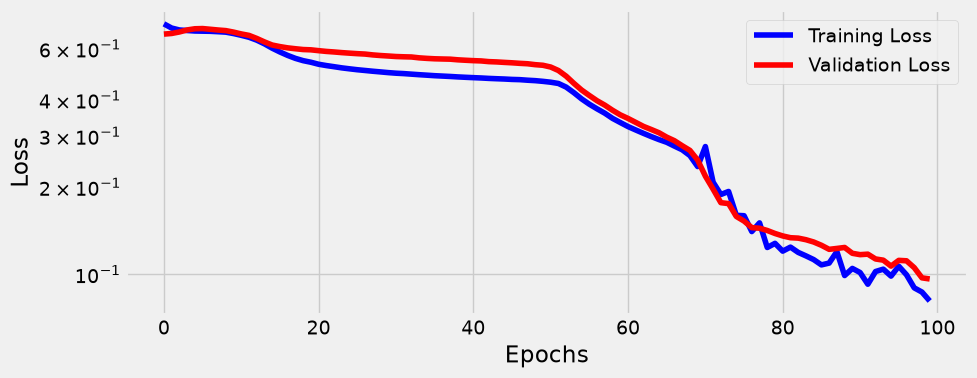

In [508]:
# 程序8-7-6: 可视化
fig = sbs_rnn.plot_losses()

In [509]:
# 程序8-7-7: 评价结果

# correct()返回的是每类的[正确数, 总数]，不是混淆矩阵
# 第0行: 类别0(逆时针↺) — 53个样本中50个预测正确, 准确率94.3%
# 第1行: 类别1(顺时针↻) — 75个样本中75个预测正确, 准确率100%
# 整体: 128个测试样本中125个正确, 准确率97.7%
StepByStep.loader_apply(test_loader, sbs_rnn.correct)

tensor([[50, 53],
        [75, 75]])

> 整个训练过程应包括: 数据生成(训练,测试),数据准备(数据集和Loader,训练数据要打乱),建立模型类(继承`nn.Module`,主要功能是`forward`前向传播)(RNN提取特征+Linear分类器),配置(模型,损失函数,优化器)(二分BCE)，训练，可视化损失，评价结果

## 可视化模型

In [510]:
# 程序8-8

# 程序8-8-1 : 查看训练后模型的RNN层参数

# 程序8-8-2: 模型对输入做相同的仿射变换，数据点独立转换

# 程序8-8-3: 可视化隐藏状态空间的决策边界：代表最终隐藏状态的样子

# 程序8-8-4: 可视化隐藏状态随时间的演化

# 程序8-8-5: 可视化训练后RNN逐时间步的特征空间变换过程（每一行初始隐藏状态都是上一行的激活状态）

# 程序8-8-6: 用完美正方形测试训练后模型, 观察最终隐藏状态

# 程序8-8-7: 可视化隐藏状态在特征空间中的路径轨迹（记录8-8-5的运行轨迹）

In [511]:
# 程序8-8-1: 查看训练后模型的RNN层参数

# 提取训练100轮后 basic_rnn 的权重和偏置
# 对比 程序8-2-1 的初始随机参数(weight_ih ≈ [[0.66,-0.42],[0.54,0.23]]),
# 这里 weight_ih_l0 = [[-0.52,-2.66],[-1.70,-0.50]] 已经完全不同,
# 说明RNN通过梯度下降学会了从2D坐标点中提取方向特征

# weight_ih_l0 形状 (hidden_dim=2, n_features=2):
#   第0行 [-0.5201, -2.6582] — 神经元0对两个输入特征的权重
#   第1行 [-1.7018, -0.4989] — 神经元1对两个输入特征的权重
# bias_ih_l0 形状 (hidden_dim=2,):
#   [0.8096, 0.8822] — 两个神经元的输入偏置

state = model.basic_rnn.state_dict()
state['weight_ih_l0'], state['bias_ih_l0']

(tensor([[-0.5201, -2.6582],
         [-1.7018, -0.4989]], device='cuda:0'),
 tensor([0.8096, 0.8822], device='cuda:0'))

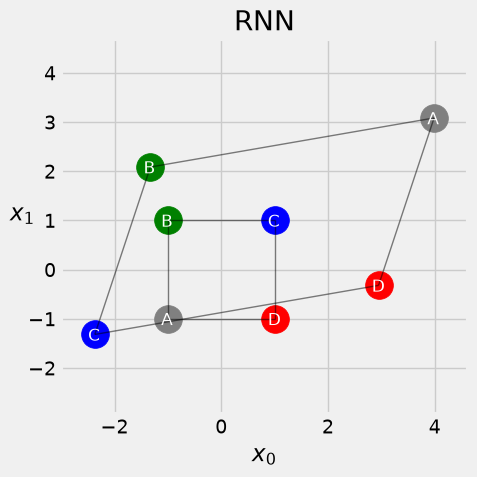

In [512]:
# 程序8-8-2: 可视化训练后RNN的输入变换

# figure13 内部流程:
#   1. 构造一个无噪声的完美正方形(顺时针A→B→C→D), 形状(1,4,2)
#   2. 拆解RNN取出 linear_input 层 (W_ih @ x + b_ih)
#   3. 调用 transformed_inputs 将4个角点分别通过 linear_input 做线性变换
#
# 图中显示两组4个点:
#   灰色/绿/蓝/红色点(右侧): 原始4个角点在2D坐标空间的位置 A(-1,-1) B(-1,1) C(1,1) D(1,-1)
#   灰色/绿/蓝/红色点(左侧): 经训练后线性层投影到隐藏空间的位置 W_ih@A+b_ih 等
#
# 设计意图: 直观展示RNN的第一步——原始几何坐标如何被线性映射到隐藏特征空间,
#         训练后的权重使得这个映射对分类任务有意义(顺时针vs逆时针)

fig = figure13(model.basic_rnn)

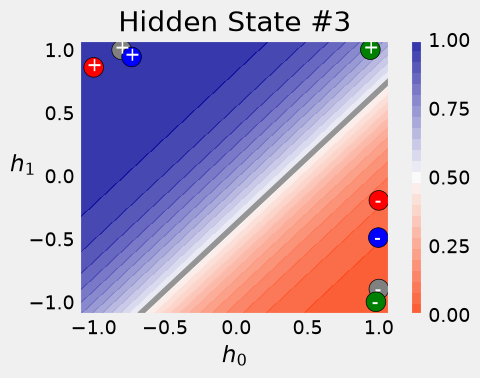

In [513]:
# 程序8-8-3: 可视化隐藏状态空间的决策边界

# canonical_contour 内部流程:
#   1. 生成8条"规范路径"(canonical sequences):
#      4条顺时针: 分别从A/B/C/D四个角出发, 沿正方形顺时针走一圈
#      4条逆时针: 分别从A/B/C/D四个角出发, 沿正方形逆时针走一圈
#      (无噪声, 每个角都是精确的[-1,-1][-1,1][1,1][1,-1])
#   2. 8条序列通过 model → 得到8个最终隐藏状态 h₃ (形状 8×2)
#   3. 在隐藏状态空间 (h₀, h₁) 上绘制 model.classifier 的概率等高线
#      并将8个隐藏状态点叠加在等高线上
#
# 图中解读:
#   背景色: 分类器在隐藏空间的决策区域
#     红色区域 → 预测为顺时针(1), 蓝色区域 → 预测为逆时针(0)
#   白色分割带: 概率≈0.5的分界区域(分类器不确定)
#   '+' 标记: 4条顺时针路径的最终隐藏状态(应落入红色区域)
#   '-' 标记: 4条逆时针路径的最终隐藏状态(应落入蓝色区域)
#
# 设计意图: 验证RNN是否学会了将不同方向的序列映射到隐藏空间中可线性分离的位置,
#          '+'和'-'泾渭分明则说明RNN成功提取了方向特征

fig = canonical_contour(model)

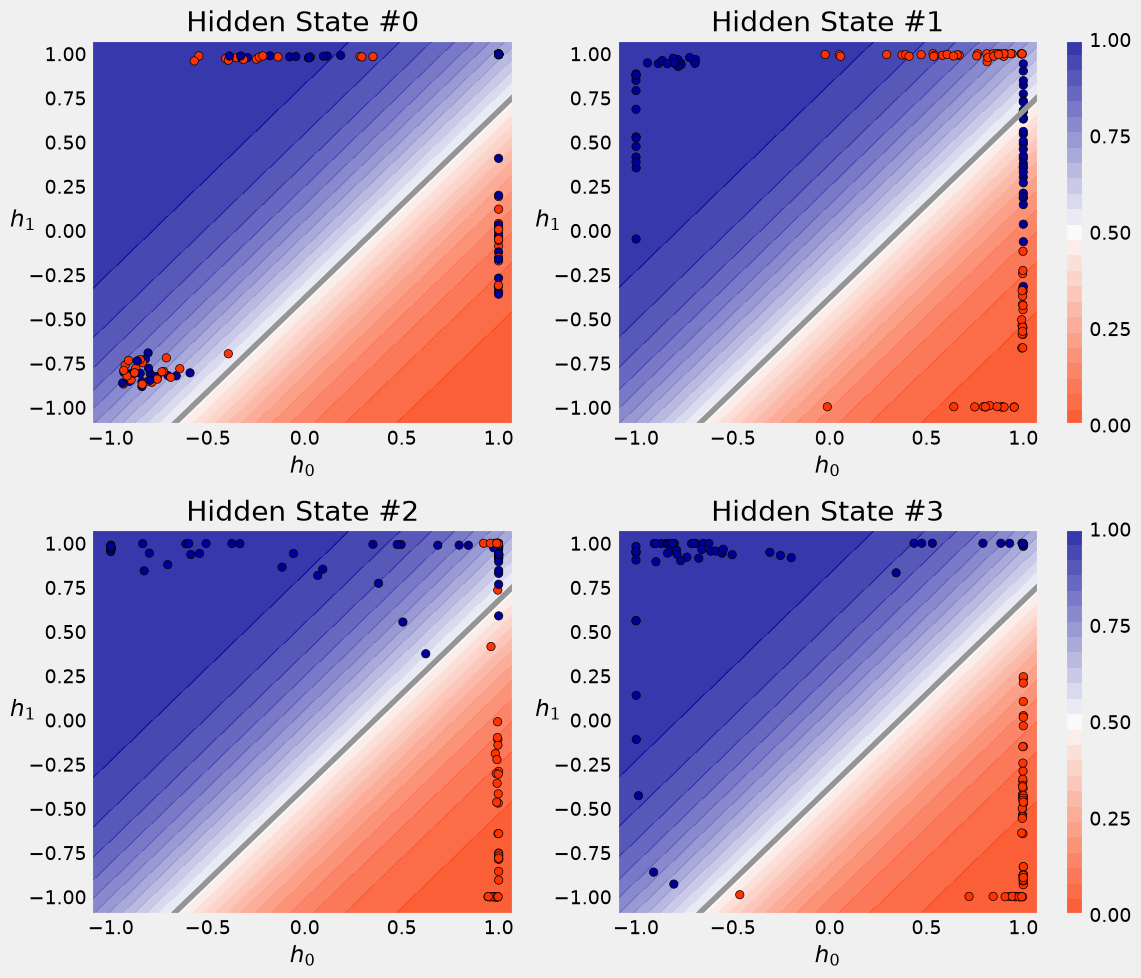

In [514]:
# 程序8-8-4: 可视化隐藏状态随时间的演化

# hidden_states_contour 内部流程:
#   2×2 子图布局, 分别对应4个时间步 (Hidden State #0 ~ #3)
#   每个子图i中:
#     - 将全部128个训练样本的前i+1个点(部分序列)送入model
#     - 取 model.hidden 在当前时间步的值作为散点坐标
#     - 背景等高线: classifier对隐藏空间中各点的概率预测
#       红色区域→预测顺时针, 蓝色区域→预测逆时针
#     - 散点颜色: 该样本的真实方向(红色=顺时针, 蓝色=逆时针)
#
# 图中解读(从左到右, 从上到下):
#   Hidden State #0: 只看了第1个点, 信息最少, 两类样本混杂在一起
#   Hidden State #1: 看了2个点, 开始出现一定的分离趋势
#   Hidden State #2: 看了3个点, 两类样本逐渐分离
#   Hidden State #3: 看完4个点的完整序列, 两类样本基本分开
#
# 设计意图: 展示信息在RNN隐藏状态中逐步累积的过程,
#         越往后两类样本在隐藏空间中分离得越清晰,
#         说明RNN确实在逐步"理解"序列的方向

fig = hidden_states_contour(model, points, directions)

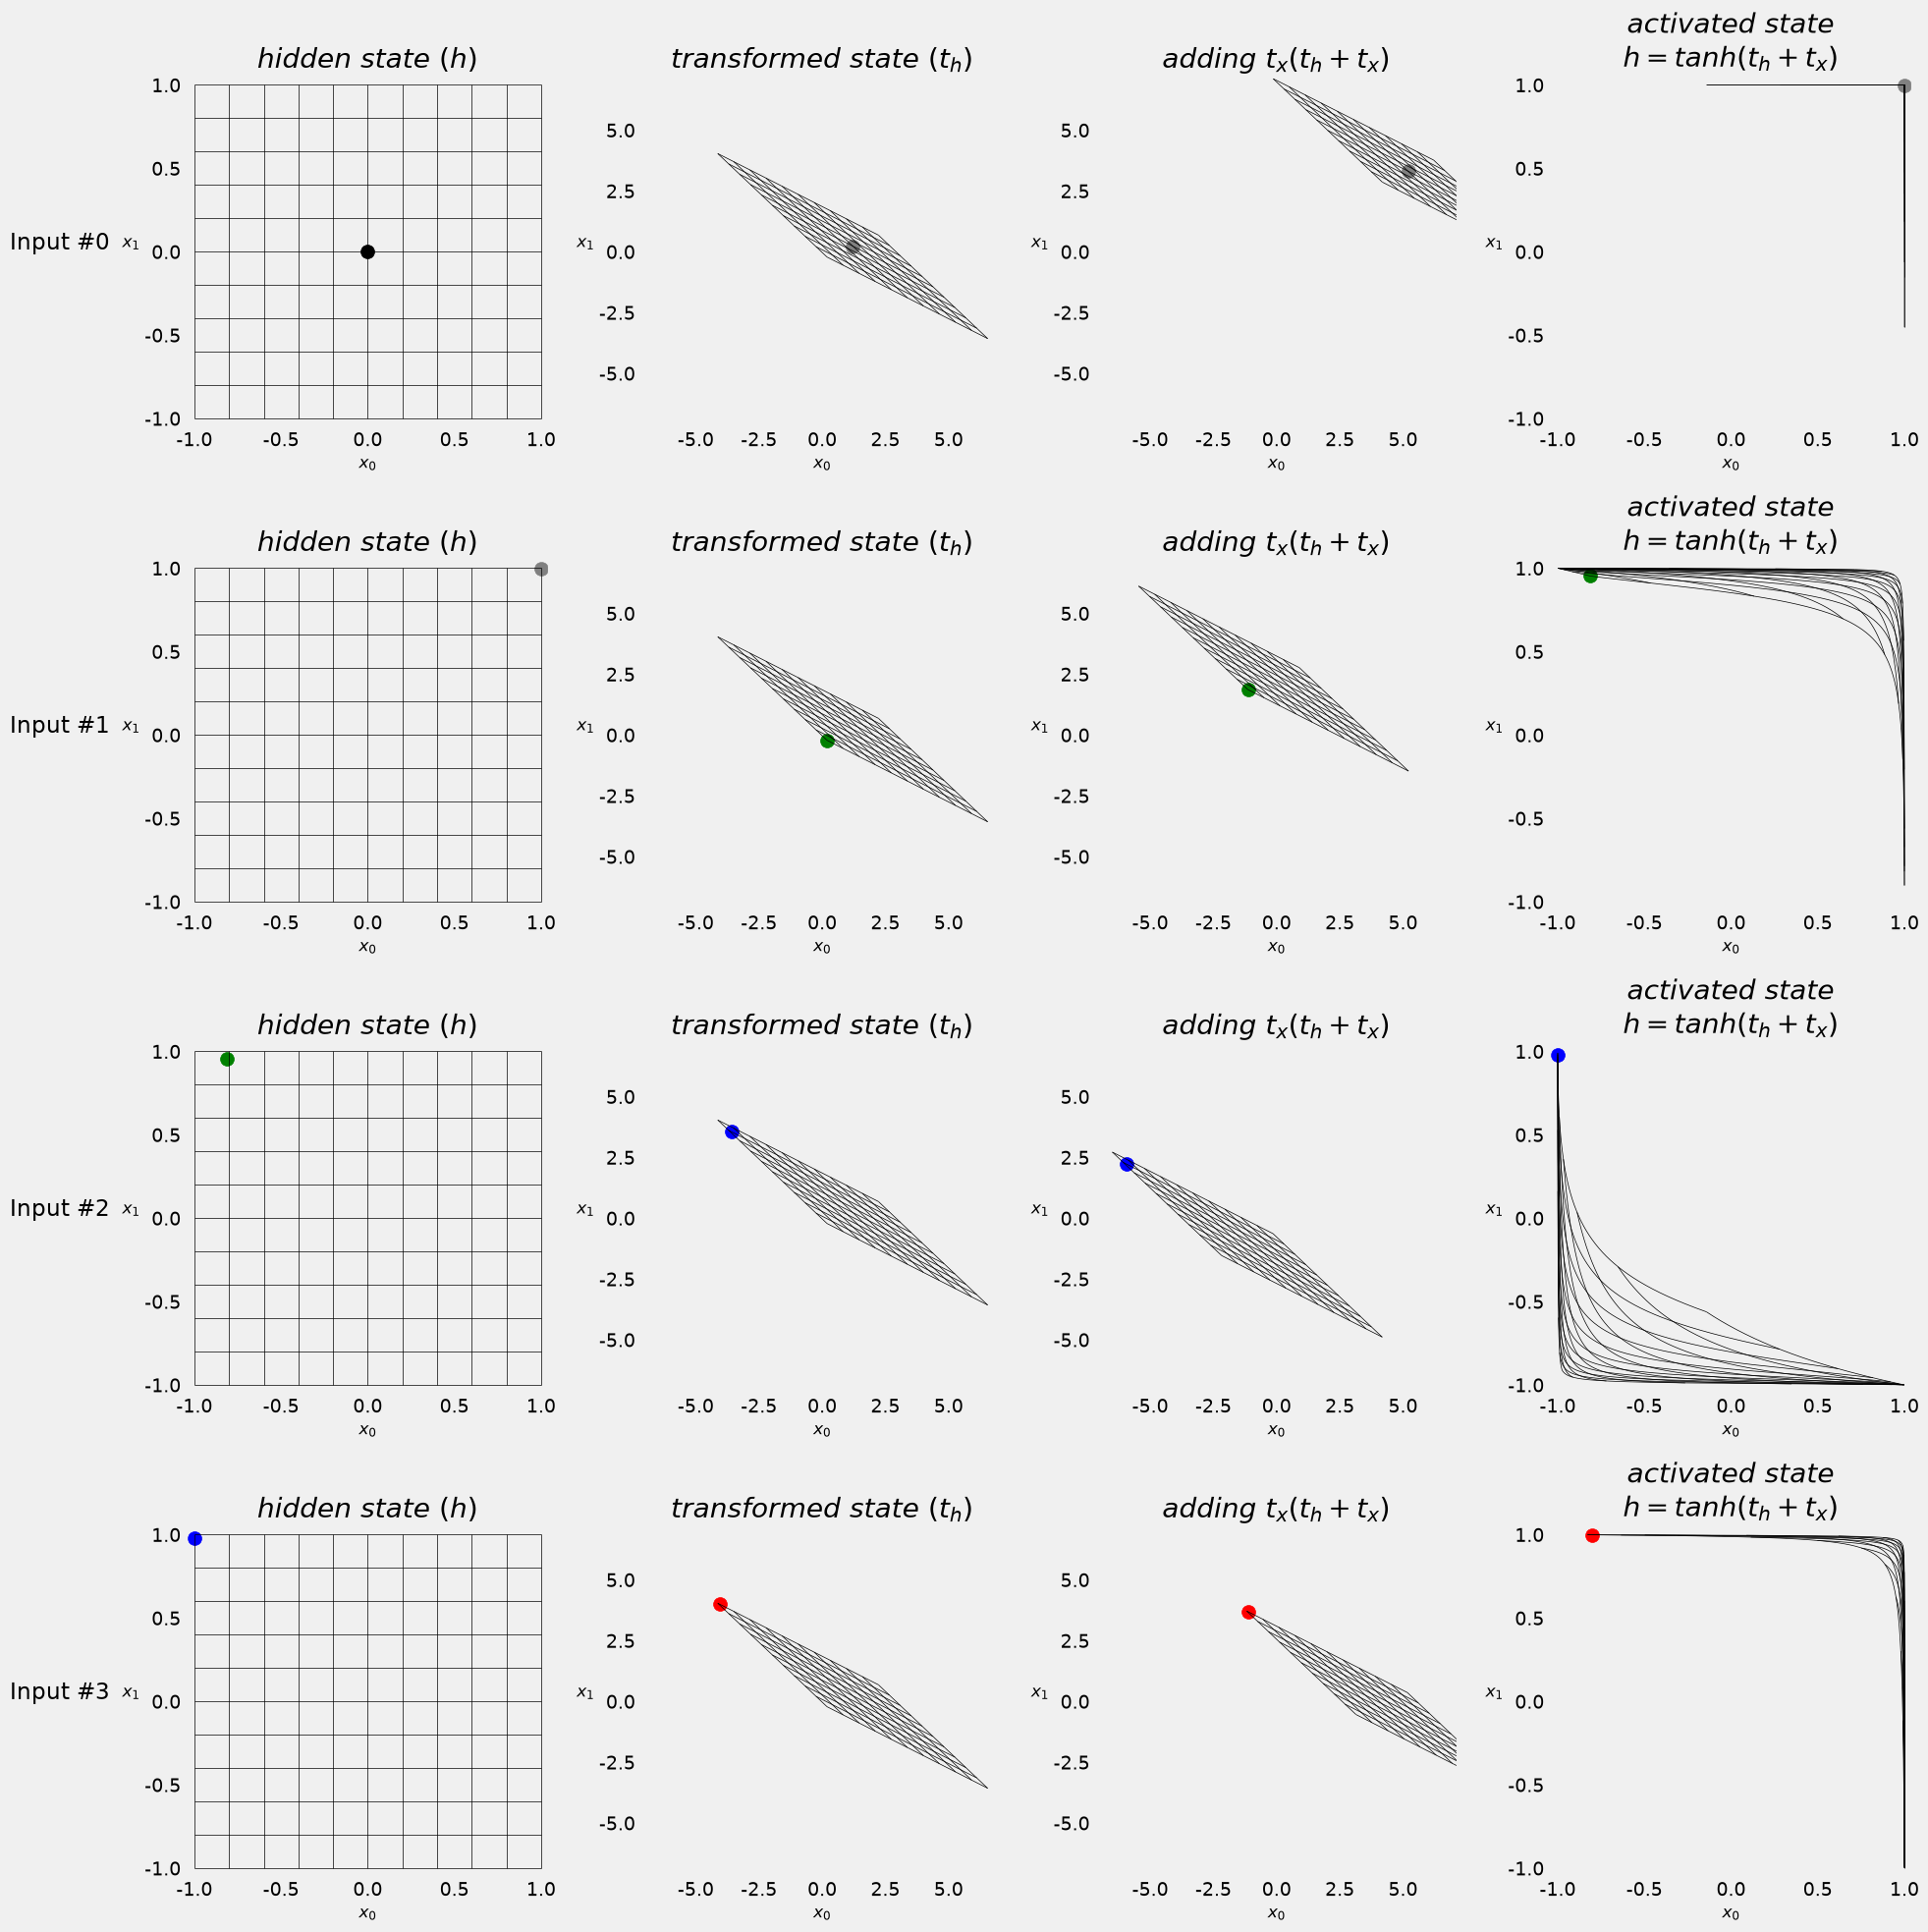

In [515]:
# 程序8-8-5: 可视化训练后RNN逐时间步的特征空间变换过程

# figure16 内部流程:
#   1. 构造完美正方形(顺时针A→B→C→D), 形状(1,4,2)
#   2. 拆解RNN取出 linear_hidden 和 linear_input 两个线性层
#   3. 调用 generate_rnn_states 手动模拟4个时间步的RNN计算,
#      记录每一步的中间状态 th, tx, th+tx, tanh(th+tx)
#   4. 调用 feature_spaces 绘制子图矩阵:
#      4行 = 4个时间步(Input #0/#1/#2/#3, 对应正方形的4个角点)
#      多列 = RNN单元内部的变换阶段
#        hidden state(h) → transformed state(t_h) → adding t_x(t_h+t_x) → activated state(h'=tanh)
#
# 图中解读:
#   每个子图中彩色点(灰/绿/蓝/红) = 正方形4个角点在该变换阶段的位置
#   横向观察: 每个角点如何经过线性变换→相加→tanh激活逐步演化
#   纵向观察: 同一变换阶段, 不同时间步的隐藏状态如何随序列推进而变化
#
# 对比 程序8-2-7 的 figure8:
#   figure8 用初始随机权重, 变换看起来杂乱无章
#   figure16 用训练100轮后的权重, 变换有明确规律,
#   各角点在隐藏空间中的位置和轨迹服务于"顺时针/逆时针"分类目标


fig = figure16(model.basic_rnn)

In [516]:
# 程序8-8-6: 用完美正方形测试训练后模型, 观察最终隐藏状态

# 构造一个无噪声的完美正方形(顺时针A→B→C→D):
#   A(-1,-1) → B(-1,1) → C(1,1) → D(1,-1)
#   形状(1,4,2): 1个样本, 4个时间步, 2个特征
#   这是顺时针方向, 标签应为1

square = torch.tensor([[-1, -1], [-1, 1], [1, 1], [1, -1]]).float().view(1, 4, 2)

# 将正方形送入训练好的模型, 触发forward计算
# forward中会将 self.hidden 更新为最终隐藏状态
model(square.to(sbs_rnn.device))

# 查看最终隐藏状态, 形状(1,1,2):
#   dim=0为层数(1层), dim=1为batch(1个样本), dim=2为隐藏特征(2维)
# 这个2维向量就是RNN对"完美顺时针正方形"的编码摘要,
# classifier将基于它预测方向
#
# 对比训练数据(含噪声σ=0.1): 无噪声正方形是"理想情况",
# 如果模型训练得当, 该隐藏状态应落入 classifier 的顺时针高概率区域

model.hidden

tensor([[[-0.8040,  0.9987]]], device='cuda:0', grad_fn=<CudnnRnnBackward0>)

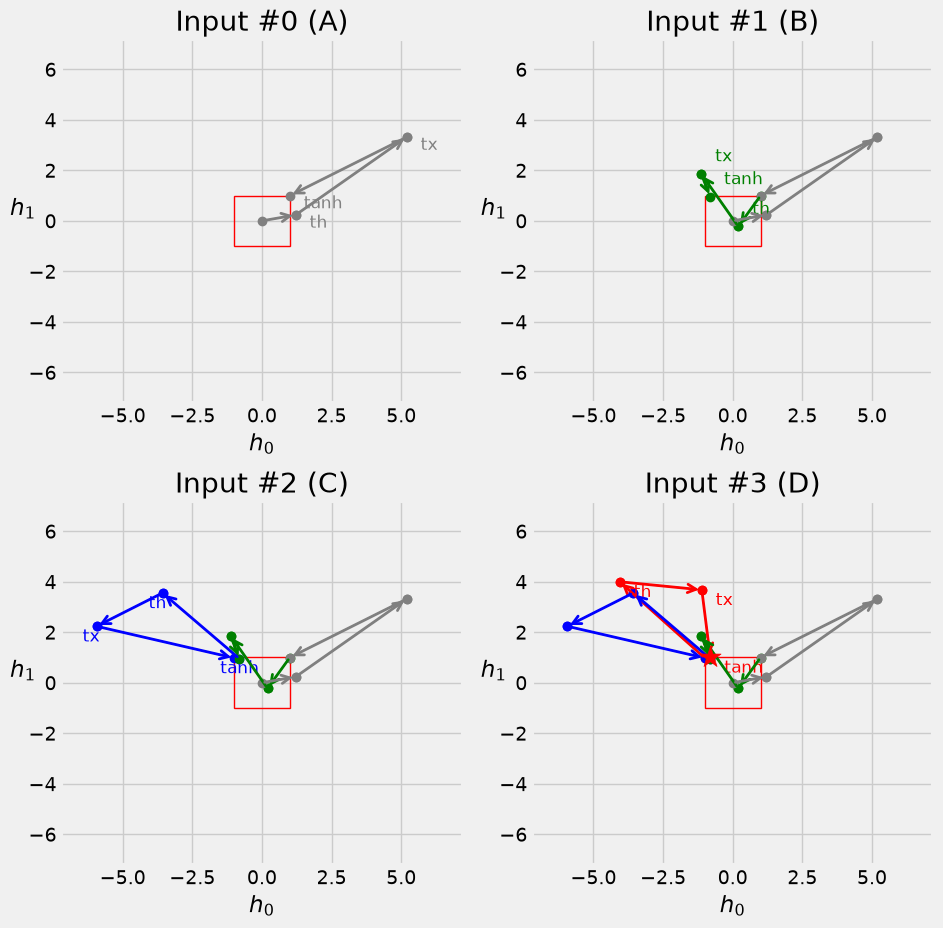

In [517]:
# 程序8-8-7: 可视化隐藏状态在特征空间中的路径轨迹

# figure17 内部流程:
#   1. 拆解训练后RNN, 取出 linear_hidden 和 linear_input
#   2. 调用 paths_clock_and_counter(only_clock=True):
#      - 构造4条顺时针序列, 分别从A/B/C/D四个角出发
#      - 对每条序列模拟RNN逐时间步处理:
#        th = linear_hidden(h)     → 隐藏层线性变换
#        tx = linear_input(x_t)    → 输入层线性变换
#        h' = tanh(th + tx)        → 新隐藏状态
#      - 在隐藏状态空间中画出每一步的轨迹:
#        th线段 → tx线段 → tanh激活线段
#
# 图中布局(2×2子图):
#   第1行(左上/右上): 分别从A和B出发的顺时针路径
#   第2行(左下/右下): 分别从C和D出发的顺时针路径
#   每个子图中矩形框: [-1,1]×[-1,1] 参考区域
#
# 轨迹解读(每个子图有3段折线×4个角点):
#   第1段(th线段): 从当前h到 W_hh@h+b_hh 的线性跳转(隐藏自变换)
#   第2段(tx线段): 加上 W_ih@x_t+b_ih 的偏移(新输入注入)
#   第3段(tanh激活): 经过tanh非线性压缩到(-1,1)范围
#   终点(★星号): 最终隐藏状态, 即RNN对完整序列的编码
#
# 设计意图: 直观展示"隐藏状态如何在特征空间中一步步移动",
#         从初始h₀=(0,0)开始, 每接收一个角点坐标后状态如何更新,
#         最终收敛到能表征"顺时针"含义的特定区域

fig = figure17(model.basic_rnn)

> 可视化RNN模型（特征空间）: 自身转换+输入转换+激活函数压缩，然后继续循环直到序列结束的过程

### 存在的问题

- 当之前隐藏状态的信息比新计算的多时
- 当数据点比隐藏状态信息多时

# 门控循环单元GRU

**Q**: 回顾
- RNN存在什么问题？


## GRU Cell

**Q**: 回答问题
- GRU是怎么解决这些问题的？（Tips:依次解决问题并作图理解比较顺应思路）
- 什么是Reset门,什么是Update门？门的逻辑是什么？

**Q**: 深入问题
- 假设r=1，输出的n等价于RNN嘛？
- 假设z=0, 状态`h'`等价于RNN嘛？
- 假设z=1, 状态`h'`有什么变化？
- 综上，r和z对状态的影响是什么？

**Q**: 结合代码
- 如何使用`GRUCell`
- GRU单元如何划分这么多权重？

$$
\Large

\text{RNN}: h'=\text{tanh}(t_h+t_x)
$$

$$
\Large
\text{GRU}: h'=\underbrace{\underbrace{\text{tanh}(\color{red}{r}*t_{hn}+t_{xn})}_{n}*\color{#0066CC}{(1-z)} + \color{gray}{h}*\color{#0066CC}{z}}_{\text{weighted average of }n\text{ and }h}
$$

$$
\Large

\color{red}{r\text{(reset gate)}}\color{red}{=\sigma(t_{hr}+t_{xr})}
\\
\color{#0066CC}{z(\text{update gate)}}\color{#0066CC}{=\sigma(t_{hz}+t_{xz})}
\\
\color{black}{n}\color{black}{=\text{tanh}(\color{red}{r}*t_{hn}+t_{xn})}
$$

$$


\color{red}{r\ (\text{hidden})}\color{red}{:t_{hr}}\color{red}{=}\color{red}{W_{hr}}\color{red}{h}\color{red}{+}\color{red}{b_{hr}}
\\
\color{red}{r\ (\text{input})}\color{red}{:t_{xr}}\color{red}{=}\color{red}{W_{ir}}\color{red}{x}\color{red}{+}\color{red}{b_{ir}}
\\
\color{#0066CC}{z\ \text{(hidden)}}\color{#0066CC}{:t_{hz}}\color{#0066CC}{=}\color{#0066CC}{W_{hz}}\color{#0066CC}{h}\color{#0066CC}{+}\color{#0066CC}{b_{hz}}
\\
\color{#0066CC}{z\ \text{(input)}}\color{#0066CC}{:t_{xz}}\color{#0066CC}{=}\color{#0066CC}{W_{iz}}\color{#0066CC}{x}\color{#0066CC}{+}\color{#0066CC}{b_{iz}}
\\
n\ \text{(hidden)}:t_{hn} = W_{hn}h+b_{hn}
\\
n\ \text{(input)}:t_{xn} = W_{in}x+b_{in}

$$

![](images/gru_cell.png)

In [518]:
# 程序8-9 手动构建GRU计算过程

# 程序8-9-1: 如何使用GRUCell(获取权重)

# 程序8-9-2: 分割权重（用来手动计算）

# 程序8-9-3: 构建线性计算函数（抽象所有线性计算）

# 程序8-9-4: 构建门和激活函数

# 程序8-9-5: 初始化

# 程序8-9-6: 两个门 + n计算 + 最终结果

# 程序8-9-7: 对比结果

In [519]:
# 程序8-9-1: 如何使用GRUCell(获取权重)
n_features = 2
hidden_dim = 2


torch.manual_seed(17)
gru_cell = nn.GRUCell(input_size=n_features, hidden_size=hidden_dim)
gru_state = gru_cell.state_dict()
print(gru_state)

OrderedDict([('weight_ih', tensor([[-0.0930,  0.0497],
        [ 0.4670, -0.5319],
        [-0.6656,  0.0699],
        [-0.1662,  0.0654],
        [-0.0449, -0.6828],
        [-0.6769, -0.1889]])), ('weight_hh', tensor([[-0.4167, -0.4352],
        [-0.2060, -0.3989],
        [-0.7070, -0.5083],
        [ 0.1418,  0.0930],
        [-0.5729, -0.5700],
        [-0.1818, -0.6691]])), ('bias_ih', tensor([-0.4316,  0.4019,  0.1222, -0.4647, -0.5578,  0.4493])), ('bias_hh', tensor([-0.6800,  0.4422, -0.3559, -0.0279,  0.6553,  0.2918]))])


In [520]:
# 程序8-9-2: 分割权重（用来手动计算）

# 注意直取权重的形状
Wx, bx = gru_state['weight_ih'], gru_state['bias_ih']
Wh, bh = gru_state['weight_hh'], gru_state['bias_hh']

print(Wx.shape, Wh.shape)
print(bx.shape, bh.shape)

# 切分权重（顺序是R-Z-N）

Wxr, Wxz, Wxn = Wx.split(hidden_dim, dim=0)
bxr, bxz, bxn = bx.split(hidden_dim, dim=0)

Whr, Whz, Whn = Wh.split(hidden_dim, dim=0)
bhr, bhz, bhn = bh.split(hidden_dim, dim=0)

print(Wxr, bxr)

print(Wxr.shape, Wxz.shape, Wxn.shape)
print(bxr.shape, bxz.shape, bxn.shape)

print(Whr.shape, Whz.shape, Whn.shape)
print(bhr.shape, bhz.shape, bhn.shape)


torch.Size([6, 2]) torch.Size([6, 2])
torch.Size([6]) torch.Size([6])
tensor([[-0.0930,  0.0497],
        [ 0.4670, -0.5319]]) tensor([-0.4316,  0.4019])
torch.Size([2, 2]) torch.Size([2, 2]) torch.Size([2, 2])
torch.Size([2]) torch.Size([2]) torch.Size([2])
torch.Size([2, 2]) torch.Size([2, 2]) torch.Size([2, 2])
torch.Size([2]) torch.Size([2]) torch.Size([2])


In [521]:
# 程序8-9-3: 构建线性计算函数（抽象所有线性计算）

def linear_layers(Wx, bx, Wh, bh):
    hidden_dim, n_features = Wx.size()    
    lin_input = nn.Linear(n_features, hidden_dim)
    lin_input.load_state_dict({'weight': Wx, 'bias': bx})
    lin_hidden = nn.Linear(hidden_dim, hidden_dim)
    lin_hidden.load_state_dict({'weight': Wh, 'bias': bh})
    return lin_hidden, lin_input

r_hidden, r_input = linear_layers(Wxr, bxr, Whr, bhr) # reset gate - red
z_hidden, z_input = linear_layers(Wxz, bxz, Whz, bhz) # update gate - blue
n_hidden, n_input = linear_layers(Wxn, bxn, Whn, bhn) # candidate state - black

In [522]:
# 程序8-9-4: 构建门和激活函数

def reset_gate(h, x):
    thr = r_hidden(h)
    txr = r_input(x)
    r = torch.sigmoid(thr + txr)
    return r  # red
    
def update_gate(h, x):
    thz = z_hidden(h)
    txz = z_input(x)
    z = torch.sigmoid(thz + txz)
    return z  # blue
    
def candidate_n(h, x, r):
    thn = n_hidden(h)
    txn = n_input(x)
    n = torch.tanh(r * thn + txn)
    return n  # black

In [523]:
# 程序8-9-5: 初始化

# 初始化隐藏层
initial_hidden = torch.zeros(1, hidden_dim)
# 选择数据点
X = torch.as_tensor(points[0]).float()
print(X.shape)
first_corner = X[0:1]
print(first_corner.shape)

torch.Size([4, 2])
torch.Size([1, 2])


In [524]:
# 程序8-9-6: 两个门 + n计算 + 最终结果

# reset门
r = reset_gate(initial_hidden, first_corner)
print(r.shape)


# 新数据计算
n = candidate_n(initial_hidden, first_corner, r)
print(n.shape)


# update门
z = update_gate(initial_hidden, first_corner)
print(z.shape)

# 更新结果

h_prime = n*(1-z) + initial_hidden*z
print(h_prime)


torch.Size([1, 2])
torch.Size([1, 2])
torch.Size([1, 2])
tensor([[-0.5635, -0.1470]], grad_fn=<AddBackward0>)


In [525]:
# 程序8-9-7: 对比结果


print(gru_cell(first_corner))

tensor([[-0.5635, -0.1470]], grad_fn=<AddBackward0>)


> GRU门控循环单元就是在RNN的基础上，解决了旧状态信息可能丢失的问题只因它加上了个门来调和旧状态对新输入和新状态的比例

> 另外门分为更新门和重置门，结构和RNN计算单元一致，重置门的输出r控制要附加多少旧状态在新输入上(tanh步)，更新门输出z控制旧状态和新状态的比例，二者都是越高越倾向老的

## GRU层

**Q**: 回答问题
- GRU层的使用和RNN有什么不同？
- 堆叠和双向对GRU是否还适用？

# 正方形模型II:GRU版本


## 模型

In [526]:
# 程序8-10-1: GRU版模型
# 设计意图: 与 SquareModel (程序8-7-3) 架构完全一致,
#          唯一区别是将 nn.RNN 替换为 nn.GRU,
#          验证GRU的门控机制是否能比普通RNN更好地捕捉序列方向

class SquareModelGRU(nn.Module):
    def __init__(self, n_features, hidden_dim, n_outputs):
        super(SquareModelGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_features = n_features
        self.n_outputs = n_outputs
        # 保存最后一层的隐藏状态，供外部检查
        self.hidden = None
        # GRU层: 与RNN不同的是内置了重置门和更新门,
        # 能自适应调节旧状态与新输入的比例, 缓解信息遗忘问题
        self.basic_rnn = nn.GRU(self.n_features, self.hidden_dim, batch_first=True)
        # 分类器: 将GRU最后一个时间步的隐藏状态映射为分类logits,
        # 输出数量与分类数一致
        self.classifier = nn.Linear(self.hidden_dim, self.n_outputs)
                
    def forward(self, X):
        # X形状: batch_first (N, L, F) — 批量大小, 序列长度, 特征数
        # batch_first_output: (N, L, H) — 每个时间步的隐藏状态
        # self.hidden: (1, N, H) — 最终隐藏状态(GRU层数=1)
        batch_first_output, self.hidden = self.basic_rnn(X)
        
        # 只取序列最后一个时间步的输出 (N, H)
        # 原因: GRU的最后一步隐藏状态已通过门控机制累积了整个序列的信息
        last_output = batch_first_output[:, -1]
        # 分类器: (N, H) → (N, n_outputs), 每个样本输出n_outputs个logits
        out = self.classifier(last_output)
        
        # 展平为 (N, n_outputs), 与标签形状对齐用于BCEWithLogitsLoss
        return out.view(-1, self.n_outputs)

## 模型配置和训练

In [527]:
# 程序8-10-2: 模型配置

torch.manual_seed(21)
# 只更换模型类
model = SquareModelGRU(n_features=2, hidden_dim=2, n_outputs=1)
loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [528]:
# 程序8-10-3: 模型训练

sbs_gru = StepByStep(model, loss, optimizer)
sbs_gru.set_loaders(train_loader, test_loader)
sbs_gru.train(100)

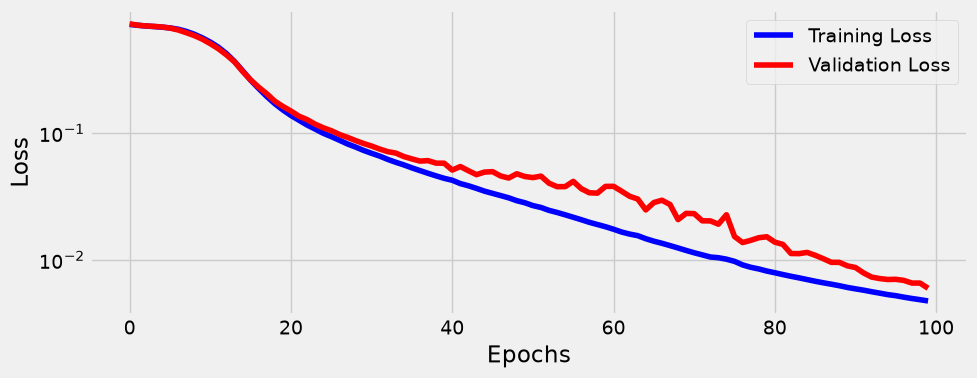

In [529]:
# 程序8-10-4: 可视化损失

fig = sbs_gru.plot_losses()

In [530]:
# 程序8-10-4: 计算准确率

StepByStep.loader_apply(test_loader, sbs_gru.correct)

tensor([[53, 53],
        [75, 75]])

> 对于GRU层实现正方形模型的改造，只要更换模型类即可

## 可视化模型

**Q**: 结合图片
- 门在特诊空间上的效果？

In [531]:
# 程序8-11

# 程序8-11-1: 对比GRU和RNN的最终状态

# 程序8-11-2: 可视化隐藏状态空间的决策边界和隐藏状态随时间的演化

# 程序8-11-3: 可视化训练后RNN逐时间步的特征空间变换过程（每一行初始隐藏状态都是上一行的激活状态）


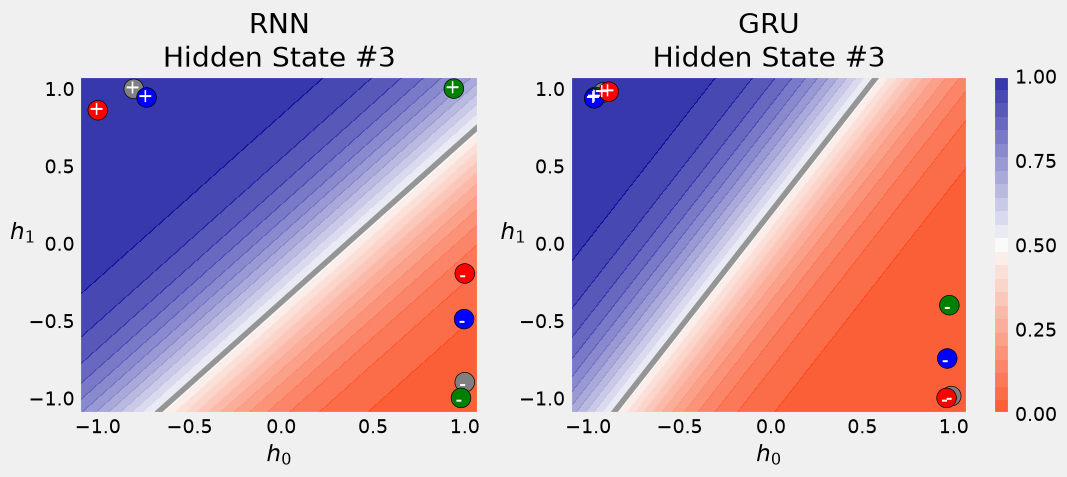

In [532]:
# 程序8-11-1: 对比GRU和RNN的最终状态

# figure20 内部流程:
#   1. 创建 1行×11列 的网格, 分为左右两个子图区域
#   2. 左侧子图(5列): 对RNN模型(sbs_rnn.model)调用 canonical_contour
#   3. 右侧子图(6列, 多1列为colorbar): 对GRU模型(sbs_gru.model)调用 canonical_contour
#
# canonical_contour 对每个模型分别做:
#   - 生成8条规范路径(4条顺时针 + 4条逆时针, 无噪声的完美正方形)
#   - 8条序列通过模型 → 得到8个最终隐藏状态(2D向量)
#   - 在隐藏状态空间绘制 classifier 的概率等高线, 叠加8个隐藏状态点
#     '+' 标记: 顺时针路径的最终隐藏状态(应落入红色高概率区域)
#     '-' 标记: 逆时针路径的最终隐藏状态(应落入蓝色低概率区域)
#
# 图中解读(左右对比):
#   RNN侧: 观察 '+' 和 '-' 的分布是否已分离, 分界线是否清晰
#   GRU侧: 观察同样8条路径在GRU隐藏空间中的分布
#   关键对比维度:
#     (a) 两类标记的分离程度 — 越分离说明模型越能区分方向
#     (b) 同一类标记的聚集程度 — 越聚集说明模型对起点不敏感(泛化好)
#     (c) 决策边界的形状 — 反映分类器在隐藏空间的划分方式
#
# 设计意图: 并排对比RNN与GRU在隐藏空间中对序列方向信息的编码能力,
#         如果GRU的 '+' 和 '-' 分离更清晰或更稳定,
#         则说明GRU的门控机制确实带来了更好的序列表征

fig = figure20(sbs_rnn.model, sbs_gru.model)

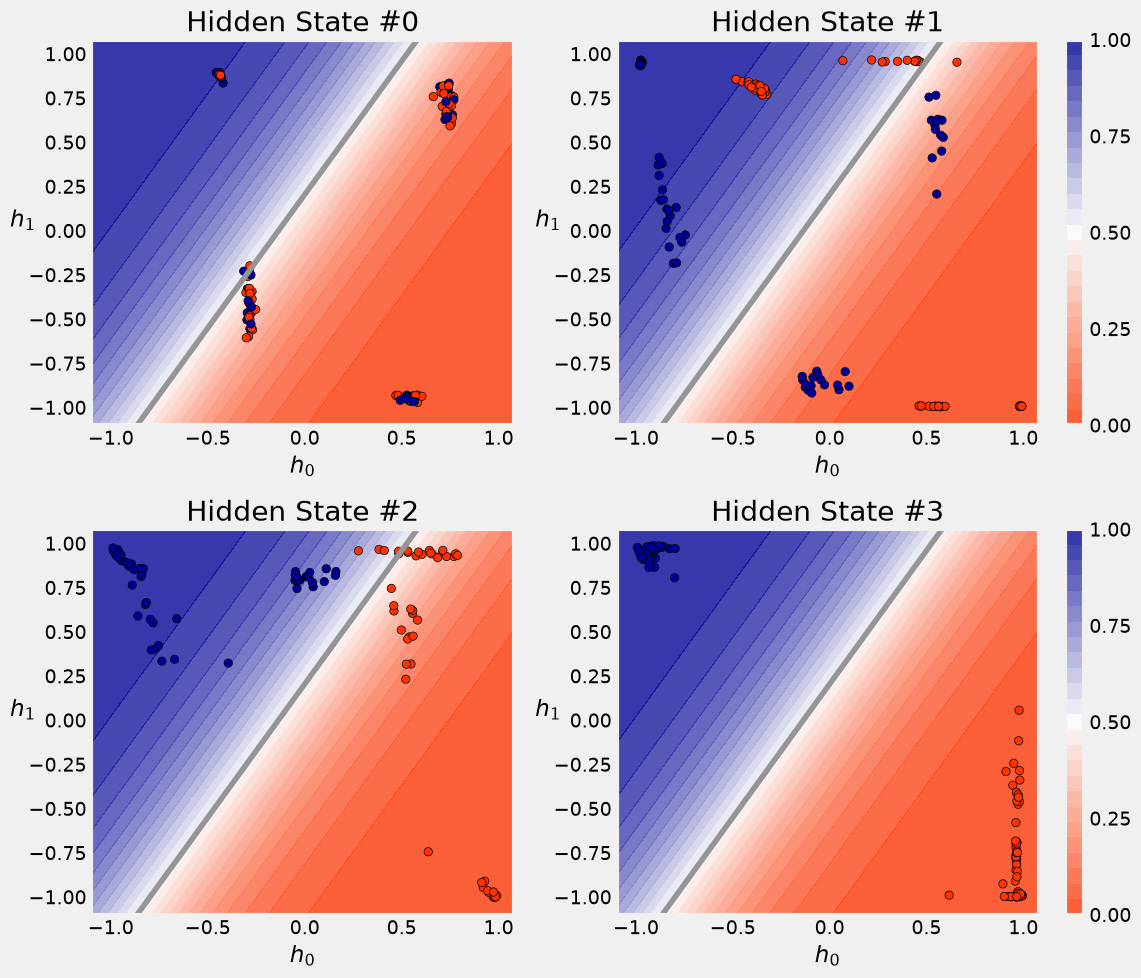

In [533]:
# 程序8-11-2: 可视化GRU隐藏状态空间的决策边界和隐藏状态随时间的演化

# hidden_states_contour 内部流程(与程序8-8-4相同逻辑, 但作用于GRU模型):
#   2×2 子图布局, 分别对应4个时间步 (Hidden State #0 ~ #3)
#   每个子图i中:
#     - 将全部128个训练样本的前i+1个点(部分序列)送入GRU模型
#     - 取 model.hidden 在当前时间步的值作为散点坐标
#     - 背景等高线: classifier对隐藏空间中各点的概率预测
#       红色区域→预测顺时针, 蓝色区域→预测逆时针
#     - 散点颜色: 该样本的真实方向(红色=顺时针, 蓝色=逆时针)
#
# 注意: 此处的 model 在程序8-10-2中已被重新赋值为 SquareModelGRU,
#      因此可视化的是GRU(而非RNN)的隐藏状态演化
#
# 图中解读(从左到右, 从上到下):
#   Hidden State #0: GRU只看了第1个点, 两类样本混杂, 但GRU的门控机制
#                    可能已开始筛选有用信息(reset门)和控制信息保留(update门)
#   Hidden State #1: 看了2个点, 开始出现分离趋势
#   Hidden State #2: 看了3个点, 两类样本进一步分离
#   Hidden State #3: 看完4个点的完整序列, 两类样本应已明显分开
#
# 对比程序8-8-4(RNN版本):
#   关键观察: GRU版本中时间步间的分离速度是否比RNN更快?
#           GRU的update门自适应调节新旧信息比例,
#           理论上能更高效地累积方向信息, 分离应更早/更明显
#           同时观察分离过程中两类样本的分布是否更紧凑(GRU泛化可能更好)
#
# 设计意图: 展示GRU的门控机制如何逐步从部分序列中提取方向信息,
#         并与RNN版本(程序8-8-4)对比, 验证门控是否带来信息累积效率的提升

fig = hidden_states_contour(model, points, directions)

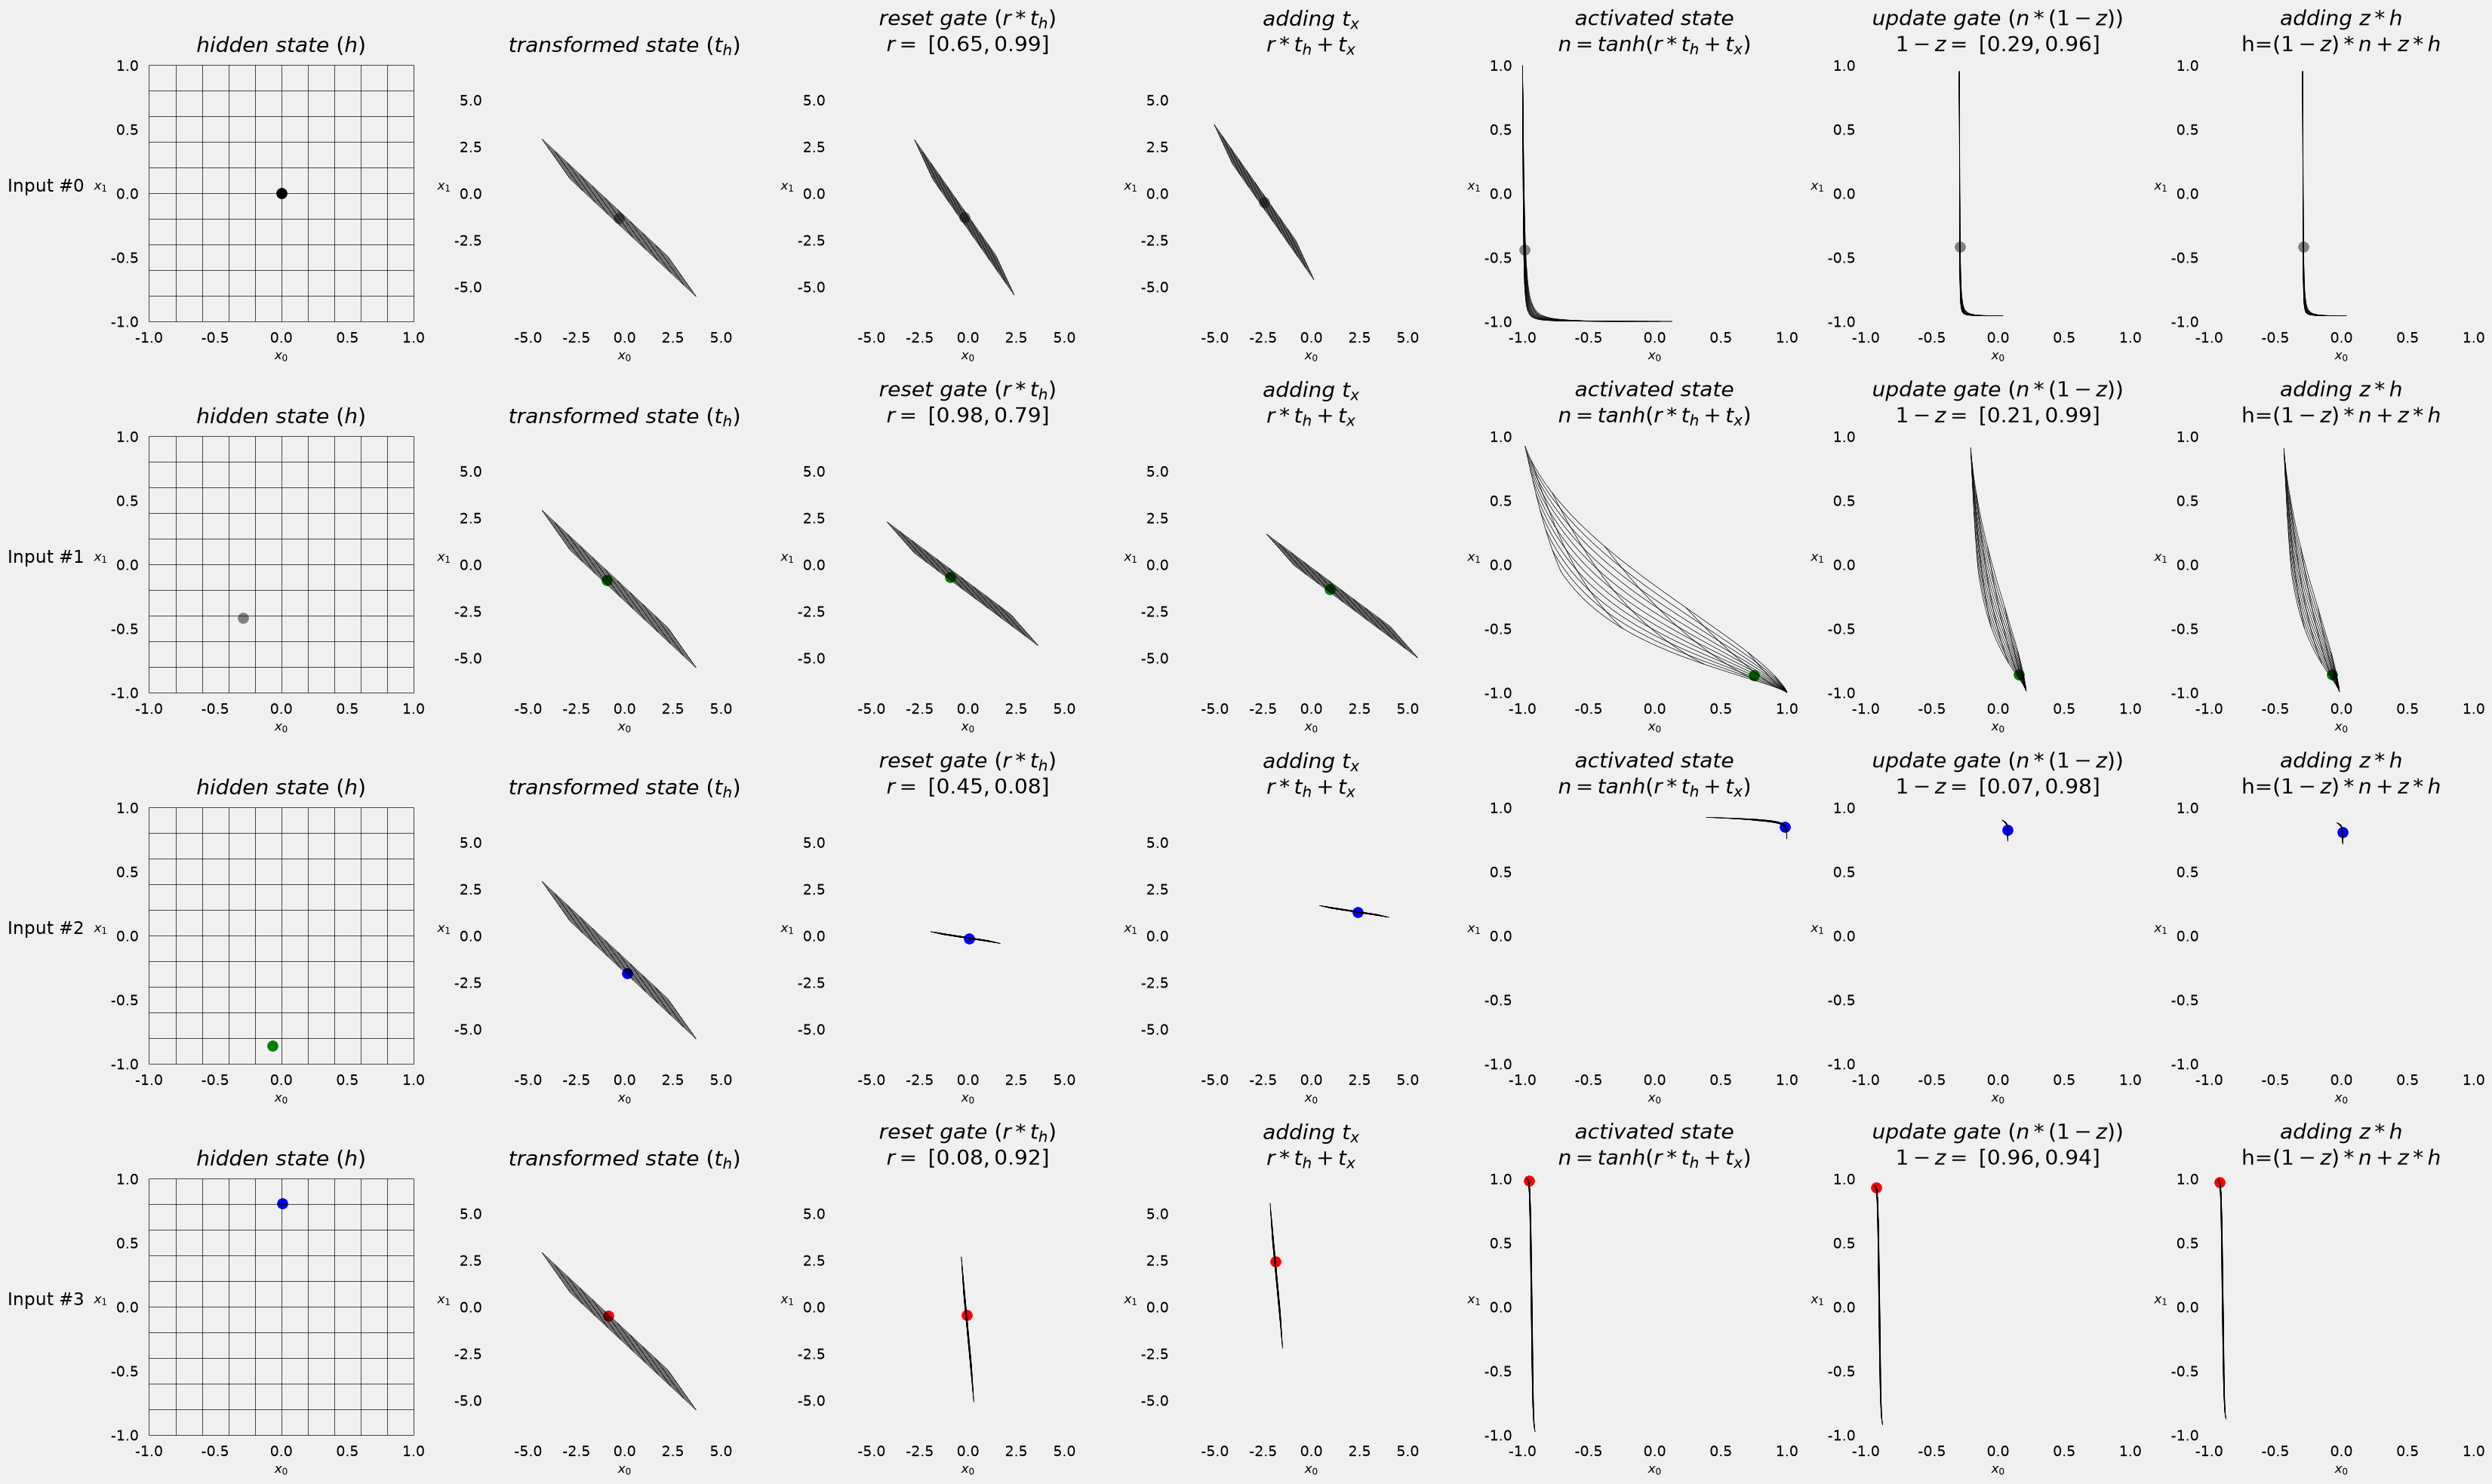

In [534]:
# 程序8-11-3: 可视化训练后GRU逐时间步的特征空间变换过程(带门控)

# figure22 内部流程:
#   1. 构造完美正方形(顺时针A→B→C→D), 形状(1,4,2)
#   2. 调用 disassemble_gru 拆解训练后的GRU层, 分离出3组线性层:
#      n_linear: 候选状态n的隐藏变换(W_hn,b_hn)和输入变换(W_in,b_in)
#      r_linear: reset门r的隐藏变换(W_hr,b_hr)和输入变换(W_ir,b_ir)
#      z_linear: update门z的隐藏变换(W_hz,b_hz)和输入变换(W_iz,b_iz)
#   3. 调用 generate_gru_states 手动模拟4个时间步的GRU计算,
#      记录每一步的门控值(r, 1-z)和中间状态
#   4. 调用 feature_spaces 绘制子图矩阵:
#      4行 = 4个时间步(Input #0/#1/#2/#3, 对应正方形的4个角点)
#      7列 = GRU单元内部的完整变换阶段(figure22独有的子图列):
#
#  列1 — hidden state (h):
#        当前时间步的隐藏状态位置, 即上一步的h'或初始化为(0,0)
#  列2 — transformed state (t_h):
#        对h做线性变换: t_h = W_hn @ h + b_hn (候选状态n的隐藏部分)
#  列3 — reset gate (r*t_h), 同时显示 r= 的值:
#        reset门的输出r乘以t_h: r*t_h
#        r = σ(W_hr@h + b_hr + W_ir@x + b_ir), 控制在t_h中保留多少旧信息
#        若r≈0则几乎"遗忘"旧状态, 若r≈1则类似普通RNN
#  列4 — adding t_x (r*t_h+t_x):
#        将门控后的隐藏变换与输入变换相加: r*t_h + t_x
#        其中 t_x = W_in @ x + b_in (输入x的线性变换)
#  列5 — activated state (n):
#        n = tanh(r*t_h + t_x), 候选新状态的激活值
#        范围(-1, 1), 代表GRU此次想写入的"新信息"
#  列6 — update gate (n*(1-z)), 同时显示 1-z= 的值:
#        n乘以(1-z): 新信息按(1-z)的比例缩放
#        z = σ(W_hz@h + b_hz + W_iz@x + b_iz)
#        若z≈1则(1-z)≈0 → 几乎忽略新信息, 保留旧状态
#        若z≈0则(1-z)≈1 → 完全采用新状态, 类似普通RNN
#  列7 — adding z*h (最终h'):
#        h' = (1-z)*n + z*h, 新旧状态的加权平均
#        这就是GRU的核心: update门z自适应调和"保留旧记忆"与"接受新信息"
#
# 图中解读:
#   横向观察: 每个角点在GRU内从h出发→t_h→重置门过滤→加t_x→tanh非线性→更新门缩放→融合旧h的全流程
#   纵向观察: 同一变换阶段, 不同时间步的隐藏状态如何随序列推进演化
#   r值变化: 观察4个时间步的reset门取值, 看GRU对序列不同位置的处理策略
#   1-z值变化: 观察4个时间步的update门取值, 看GRU何时倾向于保留旧信息,
#              何时倾向于接受新输入
#
# 对比程序8-8-5的 figure16(RNN版本):
#   RNN只有4列: h → t_h → t_h+t_x → tanh(h')
#   GRU有7列: 多了reset门过滤(r*t_h)和update门加权((1-z)*n+z*h)两个中间步骤
#   这7列正是GRU相比RNN的核心差异:
#     reset门(r) → 决定旧状态中有多少参与候选n的计算
#     update门(z) → 决定最终状态中新旧信息的混合比例
#   门控的值(r, 1-z)直接显示在子图标题中, 可以读到具体的门控信号强度
#
# 设计意图: 完整展示GRU内部7个变换阶段的"流水线",
#         直观理解 r(重置门) 和 z(更新门) 在每个时间步如何动态调节信息流,
#         从而理解GRU为何能缓解RNN的信息遗忘问题

fig = figure22(model.basic_rnn)

> 门会非常地压缩特征空间，只因门的参数是0-1之间，且不同维度不同数值，在每个维度上都有不同形式的压缩

## 存在的问题2

- 双曲正切内部使用reset门很奇怪
- 隐藏状态的优点是以双曲正切为界，保证下一单元获得相同范围内的隐藏状态
- 隐藏状态的缺点在于受双曲正切限制，限制了可取的值和梯度

### 解释（AI生成）

#### 1. "双曲正切内部使用 reset 门很奇怪"
回顾 GRU 候选状态的计算：

$$n = \tanh(\color{red}{r} * t_{hn} + t_{xn})$$

这里 reset 门 r（sigmoid 输出，范围 0~1）放在了 tanh 的内部。

"奇怪"在于两者的配合存在矛盾：

reset 门的设计意图是：r ≈ 0 时切断旧状态、让 n 只取决于当前输入 t_xn
但 tanh 有饱和区：当 |x| > ~3 时，tanh 输出逼近 ±1，梯度趋近于零
这就产生一个问题：如果当前输入 t_xn 本身就很大（比如值接近 3），那么不管 r 取 0.1 还是 0.9，r*t_hn + t_xn 都会落入 tanh 的饱和区，输出都接近 +1。换言之，tanh 的饱和特性把 reset 门的效果给"抹平"了——门控调节在饱和区几乎失效。

#### 2. 优："隐藏状态以 tanh 为界，保证下一单元获得相同范围内的隐藏状态"
这是 tanh 的正面价值。

GRU（以及 RNN）的最终隐藏状态 h' 被 tanh 输出 n 和旧状态 h 共同决定——但 n = tanh(...) 始终在 (-1, 1) 范围内。无论序列多长，每一时间步看到的隐藏状态数值量级始终保持稳定，不会像某些无约束的迭代过程那样指数爆炸。这对稳定训练是好事。

#### 3. 缺："隐藏状态受 tanh 限制，限制了可取的值和梯度"
这是 tanh 的反面代价，与第 1 点呼应：

值受限：隐藏状态只能在 (-1, 1) 范围内，意味着 2 维隐藏状态只能在单位正方形内表达信息，表达能力有限
梯度受限：tanh 在饱和区（输出接近 ±1）梯度 → 0。长序列中，时间步一多，梯度连乘就导致梯度消失——早期时间步的参数几乎得不到更新
这就是为 LSTM 做铺垫的关键：

LSTM 的 cell state c 不经过 tanh 约束——只有输出门对外暴露时才过一个 tanh，而 cell state 本身可以线性累积，梯度可以无损地在时间步间反向传播。这就是 LSTM 缓解梯度消失的核心设计。

# 长短期记忆LSTM

声明:
- GRU的出现比LSTM晚，但复杂还是LSTM复杂，所以LSTM最后说

## LSTM单元

**Q**: 回答问题
- LSTM有几个隐藏状态，分别代表了什么记忆？
- LSTM是怎么解决GRU存在的问题的？（Tips:依次解决问题并作图理解比较顺应思路）
- LSTM有哪些门，作用都是什么？

**Q**: 深入问题
- 假设`i=1`且`f=0`,效果和RNN比较如何？
- 假设`i=0`且`f=1`,状态会有什么变化？
- `o`的大小影响什么？
- 隐藏状态和单元状态有什么区别？这个区别解决了什么问题？

$$
\Large

\text{RNN}: h'=\text{tanh}(t_h+t_x)
\\
\text{GRU}: h'=\text{tanh}(r*t_{hn}+t_{xn})*(1-z)+h*z
\\
\text{LSTM}: c'=\underbrace{\text{tanh}(t_{hg}+t_{xg})}_{g}*\color{#82b366}{i}+\color{gray}{c}*\color{red}{f}
\\
h'=\text{tanh}(c')*\color{#0066cc}{o}

$$

---

$$
\Large

\color{#82b366}{i\text{(nput gate)}}=\color{#82b366}{\sigma(t_{hi}+t_{xi})}
\\
\color{red}{f\text{(orget gate)}}\color{red}{=\sigma(t_{hf}+t_{xf})}
\\
\color{#0066cc}{o\text{(utput gate)}}\color{#0066cc}{=\sigma(t_{ho}+t_{xo})}
\\
g=\text{tanh}(t_{hg}+t_{xg})

$$

---

$$
\Large
\color{#82b366}{i\ \text{(hidden)}}\color{#82b366}{:t_{hi}}\color{#82b366}{=}\color{#82b366}{W_{hi}}\color{#82b366}{h}\color{#82b366}{+}\color{#82b366}{b_{hi}}
\\
\color{#82b366}{i\ \text{(input)}}\color{#82b366}{:t_{xi}}\color{#82b366}{=}\color{#82b366}{W_{ii}}\color{#82b366}{x}\color{#82b366}{+}\color{#82b366}{b_{ii}}
\\
\color{red}{f\ \text{(hidden)}}\color{red}{:t_{hf}}\color{red}{=}\color{red}{W_{hf}}\color{red}{h}\color{red}{+}\color{red}{b_{hf}}
\\
\color{red}{f\ \text{(input)}}\color{red}{:t_{xf}}\color{red}{=}\color{red}{W_{if}}\color{red}{x}\color{red}{+}\color{red}{b_{if}}
\\
g\ \text{(hidden)}:t_{hg} = W_{hg}h+b_{hg}
\\
g\ \text{(input)}:t_{xg} = W_{ig}x+b_{ig}
\\
\color{#0066cc}{o\ \text{(hidden)}}\color{#0066cc}{:t_{ho}}\color{#0066cc}{=}\color{#0066cc}{W_{ho}}\color{#0066cc}{h}\color{#0066cc}{+}\color{#0066cc}{b_{ho}}
\\
\color{#0066cc}{o\ \text{(input)}}\color{#0066cc}{:t_{xo}}\color{#0066cc}{=}\color{#0066cc}{W_{io}}\color{#0066cc}{x}\color{#0066cc}{+}\color{#0066cc}{b_{io}}
$$

---

![](images/lstm_cell.png)

In [535]:
#程序8-12: 手动实现LSTM单元计算

#程序8-12-1: 初始化LSTM计算单元(获得权重)

#程序8-12-2: 切分参数（方便手动计算）

#程序8-12-3: 加载g临时状态的参数

#程序8-12-4: 实现各个门函数

#程序8-12-5: 初始化隐藏状态和提取数据

#程序8-12-6: 计算c状态的输入部分（本次记住多少输入？）

#程序8-12-7: 计算c状态的旧状态部分（还能保留多少记忆？）

#程序8-12-8: 汇总单元状态

#程序8-12-9: 转换（压缩或控制）本次单元状态作隐藏状态

#程序8-12-10: 对比结果（注意是两种状态）


In [536]:
#程序8-12-1: 初始化LSTM计算单元(获得权重)

n_features = 2
hidden_dim = 2

torch.manual_seed(17)
lstm_cell = nn.LSTMCell(input_size=n_features, hidden_size=hidden_dim)
lstm_state = lstm_cell.state_dict()
print(lstm_state)

OrderedDict([('weight_ih', tensor([[-0.0930,  0.0497],
        [ 0.4670, -0.5319],
        [-0.6656,  0.0699],
        [-0.1662,  0.0654],
        [-0.0449, -0.6828],
        [-0.6769, -0.1889],
        [-0.4167, -0.4352],
        [-0.2060, -0.3989]])), ('weight_hh', tensor([[-0.7070, -0.5083],
        [ 0.1418,  0.0930],
        [-0.5729, -0.5700],
        [-0.1818, -0.6691],
        [-0.4316,  0.4019],
        [ 0.1222, -0.4647],
        [-0.5578,  0.4493],
        [-0.6800,  0.4422]])), ('bias_ih', tensor([-0.3559, -0.0279,  0.6553,  0.2918,  0.4007,  0.3262, -0.0778, -0.3002])), ('bias_hh', tensor([-0.3991, -0.3200,  0.3483, -0.2604, -0.1582,  0.5558,  0.5761, -0.3919]))])


In [537]:
#程序8-12-2: 切分参数和线性层创建（方便手动计算）

Wx, bx = lstm_state['weight_ih'], lstm_state['bias_ih']
Wh, bh = lstm_state['weight_hh'], lstm_state['bias_hh']

# 切分输入数据的权重和偏置
# LSTM的4个门按顺序: i(input门), f(forget门), g(候选单元), o(output门)
Wxi, Wxf, Wxg, Wxo = Wx.split(hidden_dim, dim=0)
bxi, bxf, bxg, bxo = bx.split(hidden_dim, dim=0)
# 切分隐藏状态的权重和偏置
Whi, Whf, Whg, Who = Wh.split(hidden_dim, dim=0)
bhi, bhf, bhg, bho = bh.split(hidden_dim, dim=0)

# 为各组件创建线性层
i_hidden, i_input = linear_layers(Wxi, bxi, Whi, bhi) # 输入门(input gate) — 绿色
f_hidden, f_input = linear_layers(Wxf, bxf, Whf, bhf) # 遗忘门(forget gate) — 红色
o_hidden, o_input = linear_layers(Wxo, bxo, Who, bho) # 输出门(output gate) — 蓝色

In [538]:
#程序8-12-3: 加载g临时状态的参数

# 由于没有Reset层参数干扰，可以直接使用RNN层，不用手动拼接线性层

g_cell = nn.RNNCell(n_features, hidden_dim) # black
g_cell.load_state_dict({'weight_ih': Wxg, 'bias_ih': bxg,
                        'weight_hh': Whg, 'bias_hh': bhg})

<All keys matched successfully>

In [539]:
#程序8-12-4: 实现各个门函数

def forget_gate(h, x):
    thf = f_hidden(h)
    txf = f_input(x)
    f = torch.sigmoid(thf + txf)
    return f  # red
    
def output_gate(h, x):
    tho = o_hidden(h)
    txo = o_input(x)
    o = torch.sigmoid(tho + txo)
    return o  # blue

def input_gate(h, x):
    thi = i_hidden(h)
    txi = i_input(x)
    i = torch.sigmoid(thi + txi)
    return i  # green

In [540]:
#程序8-12-5: 初始化隐藏状态和提取数据

initial_hidden = torch.zeros(1, hidden_dim)
initial_cell = torch.zeros(1, hidden_dim)

X = torch.as_tensor(points[0]).float()
first_corner = X[0:1]

In [541]:
#程序8-12-6: 计算c状态的输入部分（本次记住多少输入？）

g = g_cell(first_corner)
i = input_gate(initial_hidden, first_corner)
gated_input = g * i
print(gated_input)

tensor([[-0.1340, -0.0004]], grad_fn=<MulBackward0>)


In [542]:
#程序8-12-7: 计算c状态的旧状态部分（还能保留多少记忆？）

f = forget_gate(initial_hidden, first_corner)
gated_cell = initial_cell * f
print(gated_cell)

tensor([[0., 0.]], grad_fn=<MulBackward0>)


In [543]:
#程序8-12-8: 汇总单元状态

c_prime = gated_cell + gated_input
print(c_prime)

tensor([[-0.1340, -0.0004]], grad_fn=<AddBackward0>)


In [544]:
#程序8-12-9: 转换（压缩或控制）本次单元状态作隐藏状态

o = output_gate(initial_hidden, first_corner)
h_prime = o * torch.tanh(c_prime)
print(h_prime, c_prime)

tensor([[-5.4936e-02, -8.3810e-05]], grad_fn=<MulBackward0>) tensor([[-0.1340, -0.0004]], grad_fn=<AddBackward0>)


In [545]:
#程序8-12-10: 对比结果（注意是两种状态）

lstm_cell(first_corner)

(tensor([[-5.4936e-02, -8.3810e-05]], grad_fn=<MulBackward0>),
 tensor([[-0.1340, -0.0004]], grad_fn=<AddBackward0>))

> GRU存在着梯度和值范围的问题，只因tanh的曲线在大于某个值后就会无限趋于1，而此时梯度也趋于0，有梯度消失的风险；同样的原因也会导致reset门的控制能力逐渐失效

> LSTM正好解决了这一问题，只因它在普通隐藏状态的基础上增加了单元状态c，且增加了输入，遗忘，输出三个门；c是不受tanh限制的，而h依然计算tanh，但会受到输出门的控制

> 另外，c的状态是靠（RNN计算新状态）和旧的c状态经过输入和遗忘门加和得出

## LSTM层

**Q**: 回答问题
- LSTM层的使用和GRU有什么不同？
- 堆叠和双向对LSTM是否还适用？

> LSTM和GRU完全相同，且堆叠和双向对LSTM也适用

# 正方形模型II

## 模型

In [546]:
#程序8-13-1: LSTM版正方形分类模型

# 设计意图: 与 SquareModel (RNN, 程序8-7-3) 和 SquareModelGRU (GRU, 程序8-10-1) 架构一致,
#          将 nn.RNN/nn.GRU 替换为 nn.LSTM,
#          LSTM的核心优势: 双状态设计 (hidden state h + cell state c) 使得梯度能在cell state中线性传播,
#          解决了GRU中tanh约束隐藏状态导致的"值受限"和"梯度消失"问题(见"存在的问题2")

class SquareModelLSTM(nn.Module):
    def __init__(self, n_features, hidden_dim, n_outputs):
        super(SquareModelLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_features = n_features
        self.n_outputs = n_outputs
        # 保存最终隐藏状态(hidden state h)，供外部检查和可视化
        self.hidden = None
        # LSTM特有: 保存最终单元状态(cell state c)，供外部检查
        # LSTM与RNN/GRU的关键区别——双状态设计:
        #   hidden state (h): 对外输出的"短期记忆"，经output门筛选，受tanh约束在(-1,1)
        #   cell state (c):   内部的"长期记忆"，不经过tanh压缩(只在更新时用tanh处理候选值g)，
        #                     梯度可在时间步之间线性反向传播(c' = g*i + c*f 是线性加法)，
        #                     这是LSTM缓解梯度消失的核心设计
        self.cell = None
        # 基础LSTM层: 将整个序列(N,L,F)编码为每个时间步的隐藏表示(N,L,H)
        # LSTM内部有4个门控: i(input门/绿色), f(forget门/红色), g(候选单元/黑色), o(output门/蓝色)
        # cell state更新: c' = g*i + c*f (不含tanh，梯度可线性流动)
        # hidden state输出: h' = tanh(c') * o (对外暴露时经过tanh压缩+output门筛选)
        self.basic_rnn = nn.LSTM(self.n_features, self.hidden_dim, batch_first=True) 
        # 分类器: 将LSTM最后一个时间步的hidden state映射为n_outputs个logits
        # 注意: 使用的是hidden state(h)而非cell state(c),
        # 因为h是LSTM对外输出的"可见状态"，已由output门控制暴露多少信息
        self.classifier = nn.Linear(self.hidden_dim, self.n_outputs)
                
    def forward(self, X):
        # X形状: batch_first格式 (N, L, F) — 批量大小, 序列长度, 特征数
        # batch_first_output: (N, L, H) — 每个时间步的隐藏状态(即h，非cell state)
        # self.hidden: (1, N, H) — 最终隐藏状态(层数=1时的维度)
        # self.cell: (1, N, H) — 最终单元状态(层数=1时的维度)
        # 注意: LSTM的返回值是 (output, (h_n, c_n))，与RNN/GRU的 (output, h_n) 不同
        #       因为LSTM有两种状态(h和c)需要同时返回
        batch_first_output, (self.hidden, self.cell) = self.basic_rnn(X)
        
        # 只取序列最后一个时间步的隐藏状态: (N, 1, H) → (N, H)
        # 意图: LSTM的最后一步hidden state已通过4个门的协同累积了整个序列的方向信息
        last_output = batch_first_output[:, -1]
        # 分类器: (N, H) → (N, n_outputs), 将隐藏状态映射为分类logits
        out = self.classifier(last_output)
        
        # 展平为 (N, n_outputs), 与标签形状对齐用于BCEWithLogitsLoss
        return out.view(-1, self.n_outputs)

## 模型配置和训练

In [547]:
#程序8-13-2: 配置LSTM模型、损失函数和优化器

# 与RNN版(程序8-7-4)和GRU版(程序8-10-2)的配置完全一致:
#   模型: SquareModelLSTM (LSTM替代RNN/GRU, 双状态设计)
#   损失: BCEWithLogitsLoss (二分类, 顺时针/逆时针)
#   优化器: Adam (lr=0.01)
# 唯一区别是模型类换成SquareModelLSTM
torch.manual_seed(21)
model = SquareModelLSTM(n_features=2, hidden_dim=2, n_outputs=1)
loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [548]:
#程序8-13-3: 训练LSTM模型100轮

# 训练流程与RNN(程序8-7-5)和GRU(程序8-10-3)完全一致,
# 使用相同的训练/测试数据加载器(train_loader, test_loader)
# sbs_lstm内部记录每轮损失，供后续可视化
sbs_lstm = StepByStep(model, loss, optimizer)
sbs_lstm.set_loaders(train_loader, test_loader)
sbs_lstm.train(100)

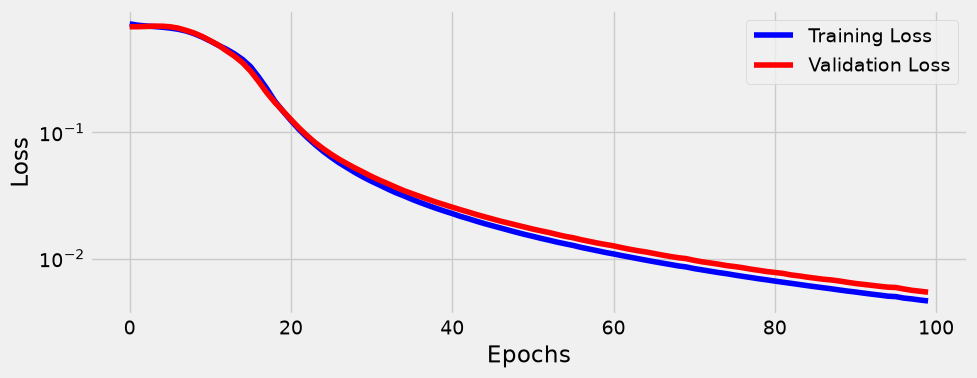

In [549]:
#程序8-13-4: 可视化LSTM训练损失曲线

# 绘制训练集和验证集损失随epoch的变化曲线
# 可与RNN版(程序8-7-6)和GRU版(程序8-10-4)的损失曲线对比:
#   观察LSTM的收敛速度是否更快、最终损失是否更低
fig = sbs_lstm.plot_losses()

In [550]:
#程序8-13-5: 评估LSTM模型在测试集上的准确率

# correct() 返回每类的[正确数, 总数]，不是混淆矩阵
# 第0行: 类别0(逆时针↺) — 53个测试样本中预测正确的数量
# 第1行: 类别1(顺时针↻) — 75个测试样本中预测正确的数量
# 可与RNN版(程序8-7-7)和GRU版(程序8-10-4)的结果对比:
#   RNN: [[50,53],[75,75]] — 逆时针有3个错误
#   GRU: [[53,53],[75,75]] — 全部正确(100%)
#   LSTM预期也应达到100%准确率，说明3种结构在此任务上都足够强
StepByStep.loader_apply(test_loader, sbs_lstm.correct)

tensor([[53, 53],
        [75, 75]])

## 可视化模型

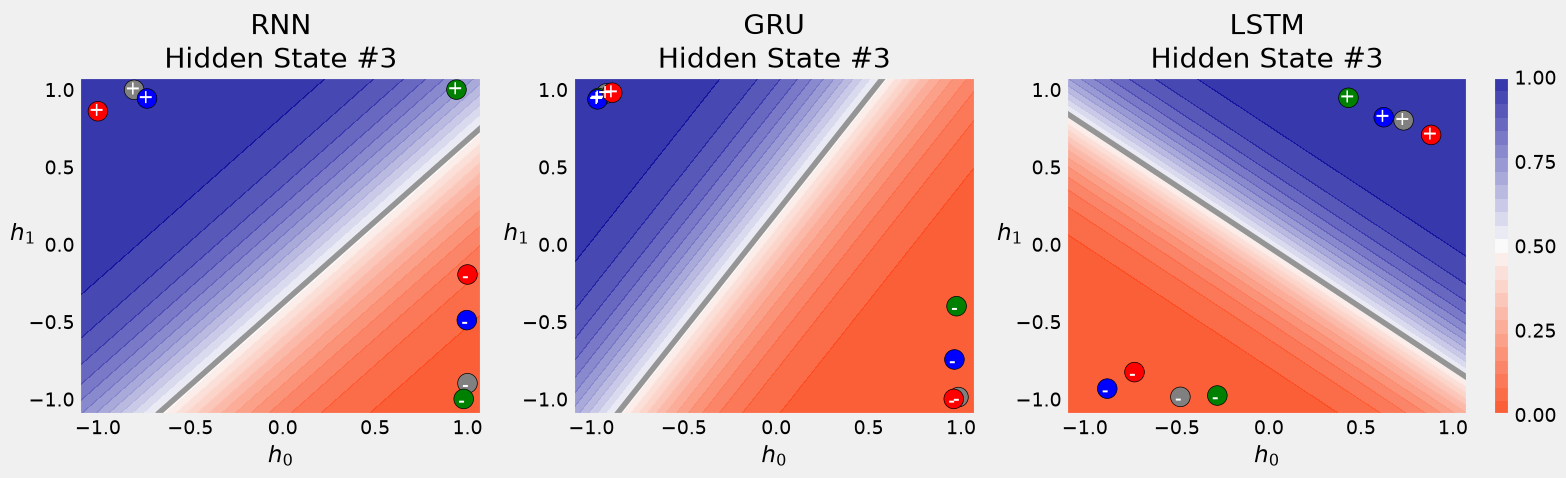

In [551]:
#程序8-14-1: 三模型决策边界对比 —— RNN vs GRU vs LSTM

# figure25 内部流程:
#   创建 1行×16列 的网格，分为3个子图区域:
#     左侧(5列): RNN模型的 canonical_contour
#     中间(5列): GRU模型的 canonical_contour
#     右侧(6列, 多1列为colorbar): LSTM模型的 canonical_contour
#
# canonical_contour 对每个模型分别做:
#   - 生成8条规范路径(4条顺时针 + 4条逆时针, 无噪声完美正方形)
#   - 8条序列通过模型 → 得到8个最终隐藏状态(2D向量)
#   - 在隐藏状态空间绘制 classifier 的概率等高线, 叠加8个隐藏状态点
#     '+' 标记: 顺时针路径的最终隐藏状态(应落入红色高概率区域)
#     '-' 标记: 逆时针路径的最终隐藏状态(应落入蓝色低概率区域)
#
# 图中解读(三栏对比):
#   关键观察维度:
#     (a) 两类标记的分离程度 — 越分离说明模型越能区分方向
#     (b) 同一类标记的聚集程度 — 越聚集说明模型对起点不敏感(泛化好)
#     (c) 不同模型间的差异 — LSTM的双状态设计是否带来更清晰的分离
#
# 设计意图: 将RNN、GRU、LSTM三种架构的隐藏空间表征并排对比,
#         直观比较三种循环单元对序列方向信息的编码能力
fig = figure25(sbs_rnn.model, sbs_gru.model, sbs_lstm.model)

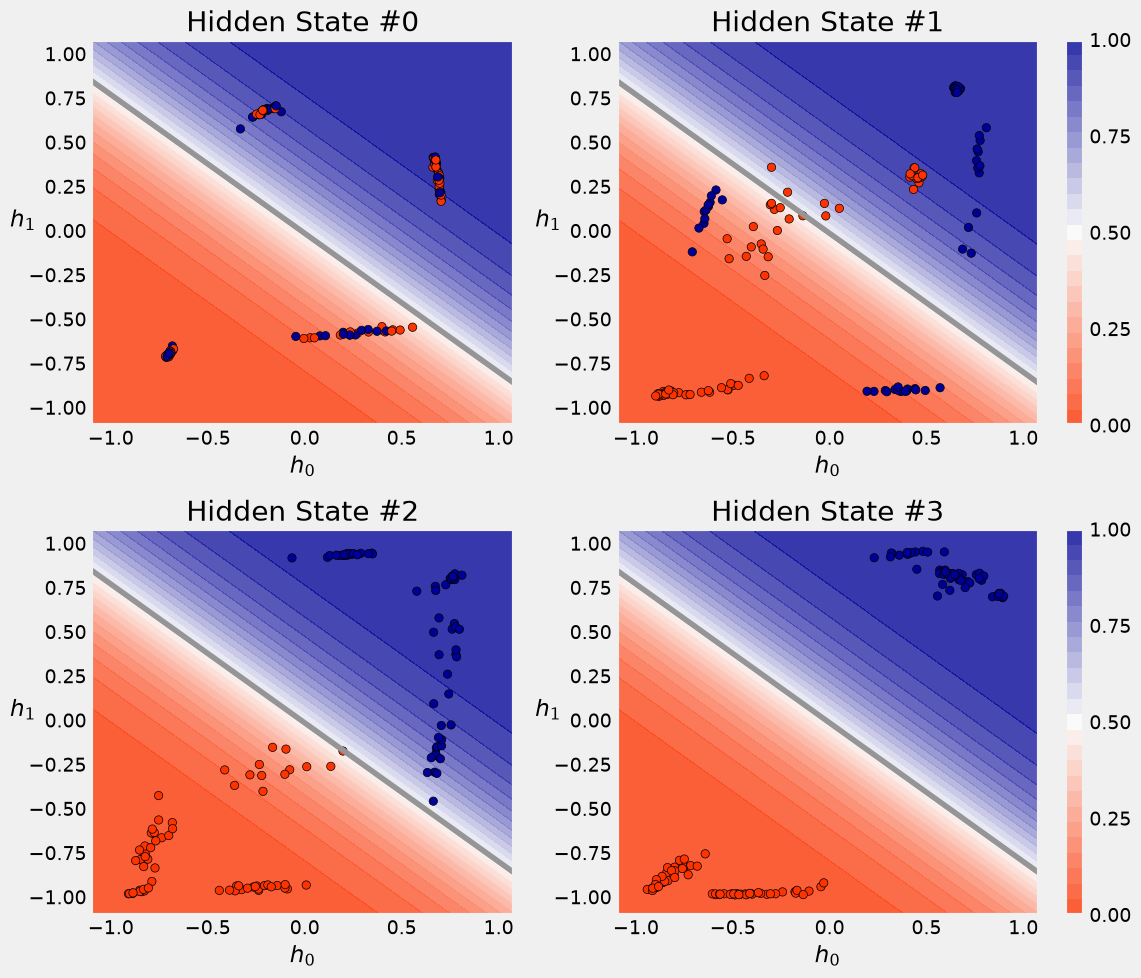

In [552]:
#程序8-14-2: 可视化LSTM隐藏状态空间的决策边界和隐藏状态随时间的演化

# 总结:看到第三个点就能正确分类大多数

# hidden_states_contour 内部流程(与程序8-8-4/程序8-11-2相同逻辑, 但作用于LSTM模型):
#   2×2 子图布局, 分别对应4个时间步 (Hidden State #0 ~ #3)
#   每个子图i中:
#     - 将全部128个训练样本的前i+1个点(部分序列)送入LSTM模型
#     - 取 model.hidden 在当前时间步的值作为散点坐标
#       注意: 这里只取hidden state (h), 不含cell state (c),
#       h是LSTM对外输出的"可见状态", 经tanh约束在(-1,1),
#       c是内部"长期记忆", 不经过tanh压缩, 但hidden_states_contour不展示c
#     - 背景等高线: classifier对隐藏空间中各点的概率预测
#       红色区域→预测顺时针, 蓝色区域→预测逆时针
#     - 散点颜色: 该样本的真实方向(红色=顺时针, 蓝色=逆时针)
#
# 注意: 此处的 model 已在程序8-13-2中被赋值为 SquareModelLSTM
#
# 图中解读(从左到右, 从上到下):
#   Hidden State #0: 只看了第1个点, 信息最少, 两类混杂
#   Hidden State #1: 看了2个点, LSTM的4个门开始协同提取方向特征, 初步分离
#   Hidden State #2: 看了3个点, cell state中长期记忆逐步累积, 分离更明显
#   Hidden State #3: 看完完整序列, 两类完全分离, 展示了LSTM双状态设计的有效性
#
# 对比程序8-8-4(RNN)和程序8-11-2(GRU):
#   观察LSTM的分离速度和质量是否优于RNN/GRU
#   LSTM的cell state使梯度线性流动, 理论上学习长程依赖更高效
#   注意: 此图只展示hidden state h的演化, cell state c是"隐藏的",
#        这是LSTM可视化的一个局限
#
# 设计意图: 展示LSTM双状态门控机制逐步提取方向信息的过程,
#         与RNN/GRU版本对比, 验证双状态设计是否带来效率和质量的双重提升

fig = hidden_states_contour(model, points, directions)


> 从结果来看，LSTM效果比GRU要好，只因最后一幅图LSTM在第三步就基本实现分类

> 另外，代码方面并无过大改动，只因逻辑皆系于模型类，只要改为LSTM模型类即可，而模型类也只替换分类器部分和添加c状态变量

# 可变长度序列

**Q**: 回顾
- 填充是什么意思？填充值是多少？在哪里用到过？

**Q**: 回答问题
- 可变长度序列是什么意思？会导致什么问题？


## 填充

**Q**: 回答问题
- 填充长度以什么为准？

**Q**: 结合代码结果
- 填充点为0是否意味着其不会改变隐藏状态？


In [553]:
# 引入
from torch.nn.utils import rnn as rnn_utils

In [554]:
#程序8-15-1: 生成可变长度数据
s0 = points[0]      # 4 data points
s1 = points[1][2:]  # 2 data points
s2 = points[2][1:]  # 3 data points

print(s0.shape, s1.shape, s2.shape)

(4, 2) (2, 2) (3, 2)


In [555]:
#程序8-15-2: 不填充导致的问题

all_seqs = [s0, s1, s2]
print(all_seqs)
# ValueError: expected sequence of length 4 at dim 1 (got 2)
#torch.as_tensor(all_seqs)

[array([[ 1.03487506,  0.96613817],
       [ 0.80546093, -0.91690943],
       [-0.82507582, -0.94988627],
       [-0.86696831,  0.93424827]]), array([[-1.09113448,  0.92538647],
       [-1.07709685, -1.04139537]]), array([[-1.12473362, -0.9682829 ],
       [ 0.81815786, -0.99443078],
       [ 1.00808662,  0.76801524]])]


In [556]:
#程序8-15-3: 填充的使用方法

seq_tensors = [torch.as_tensor(seq).float() for seq in all_seqs]
padded = rnn_utils.pad_sequence(seq_tensors, batch_first=True)
print(padded)

tensor([[[ 1.0349,  0.9661],
         [ 0.8055, -0.9169],
         [-0.8251, -0.9499],
         [-0.8670,  0.9342]],

        [[-1.0911,  0.9254],
         [-1.0771, -1.0414],
         [ 0.0000,  0.0000],
         [ 0.0000,  0.0000]],

        [[-1.1247, -0.9683],
         [ 0.8182, -0.9944],
         [ 1.0081,  0.7680],
         [ 0.0000,  0.0000]]])


In [557]:
#程序8-15-4: 利用填充后的数据进行RNN计算

torch.manual_seed(11)
rnn = nn.RNN(2, 2, batch_first=True)

output_padded, hidden_padded = rnn(padded)
print(output_padded)
print(hidden_padded)

tensor([[[-0.6388,  0.8505],
         [-0.4215,  0.8979],
         [ 0.3792,  0.3432],
         [ 0.3161, -0.1675]],

        [[ 0.2911, -0.1811],
         [ 0.3051,  0.7055],
         [ 0.0052,  0.5819],
         [-0.0642,  0.6012]],

        [[ 0.3385,  0.5927],
         [-0.3875,  0.9422],
         [-0.4832,  0.6595],
         [-0.1007,  0.5349]]], grad_fn=<TransposeBackward1>)
tensor([[[ 0.3161, -0.1675],
         [-0.0642,  0.6012],
         [-0.1007,  0.5349]]], grad_fn=<StackBackward0>)


In [558]:
#程序8-15-5: 换回LNH格式状态
print(hidden_padded.permute(1, 0, 2))

tensor([[[ 0.3161, -0.1675]],

        [[-0.0642,  0.6012]],

        [[-0.1007,  0.5349]]], grad_fn=<PermuteBackward0>)


> 对于变长序列，填充是必须的，只因填充会把所有序列按最大长度填充0来对齐，从而避免变长序列无法转换为张量

> 另外，即使是填充的0点，仍然会对隐藏状态造成影响，若要避免，可使用打包技术

## 打包

Tips：
- ONNX导出模型时，才需要`enforce_sorted`排序

**Q**: 回答问题
- 打包的工作方式是什么？
- 打包后的格式是什么？
- 打包序列经过RNN处理输出和隐藏状态是否为打包格式？

**Q**: 结合代码
- 如何创建一个打包的序列？
- `enforce_sorted`参数代表什么？
- `PackedSequence`的结构代表了什么

**Q**: 结合AI注释
- 为什么双向网络获取最终隐藏状态时需要解包？

![](images/packed_seq_inddata.png)

---

![](images/packed_seq_data.png)


In [559]:
#程序8-16: 打包格式实验

#程序8-16-1: 使用pack_sequence打包变长序列，避免填充零的浪费

#程序8-16-2: 验证打包数据的完整性——packed.data的索引映射关系

#程序8-16-3: 将打包序列输入RNN，RNN自动跳过填充位置

#程序8-16-4: 验证打包与填充的最终隐藏状态完全一致

#程序8-16-5: 从打包输出中按索引提取指定序列的数据

In [560]:
#程序8-16-1: 使用pack_sequence打包变长序列，避免填充零的浪费

# pack_sequence vs pad_sequence(程序8-15-3):
#   pad_sequence: 将所有序列填充到最大长度, 短序列末尾补0
#                 缺点: 填充的0点仍参与RNN计算, 浪费算力且会污染隐藏状态
#   pack_sequence: 将所有序列的真实数据按时间步首尾拼接成紧凑的1D张量,
#                 不含任何填充零, RNN只在有效位置上计算, 效率更高
#
# PackedSequence结构:
#   .data: 按时间步优先排列的拼接数据(不是按序列)
#     t=0: [s0[0], s2[0], s1[0]]  — 3个有效批次
#     t=1: [s0[1], s2[1], s1[1]]  — 3个有效批次
#     t=2: [s0[2], s2[2]]         — 2个有效批次(s1已结束)
#     t=3: [s0[3]]                — 1个有效批次(s2也结束了)
#   .batch_sizes: [3, 3, 2, 1]  — 每个时间步有多少个序列仍有效
#   .sorted_indices: 按长度降序排列的索引(长序列在前)
#   .unsorted_indices: 用于恢复原始顺序的索引
#
# enforce_sorted=False: 允许任意顺序传入序列,
#   PyTorch内部自动按长度降序排列(RNN要求长序列→短序列),
#   排列信息记录在sorted_indices/unsorted_indices中

packed = rnn_utils.pack_sequence(seq_tensors, enforce_sorted=False)
print(packed)

PackedSequence(data=tensor([[ 1.0349,  0.9661],
        [-1.1247, -0.9683],
        [-1.0911,  0.9254],
        [ 0.8055, -0.9169],
        [ 0.8182, -0.9944],
        [-1.0771, -1.0414],
        [-0.8251, -0.9499],
        [ 1.0081,  0.7680],
        [-0.8670,  0.9342]]), batch_sizes=tensor([3, 3, 2, 1]), sorted_indices=tensor([0, 2, 1]), unsorted_indices=tensor([0, 2, 1]))


In [561]:
#程序8-16-2: 验证打包数据的完整性——packed.data的索引映射关系

# packed.data按时间步优先排列, 而非按序列优先(见程序8-16-1注释)
# packed.data中s0的4个点分布在索引[0, 3, 6, 8]位置:
#   索引0(t=0, batch位0), 索引3(t=1, batch位0),
#   索引6(t=2, batch位0), 索引8(t=3, batch位0)
#   这些位置分别对应s0在4个时间步的输入,
#   所以 == seq_tensors[0] 应为全True
#
# 设计意图: 验证打包操作正确保持了数据的顺序和内容,
#         确认packed.data中每个时间步的数据与原始序列一致

(packed.data[[0, 3, 6, 8]] == seq_tensors[0]).all()

tensor(True)

In [562]:
#程序8-16-3: 将打包序列输入RNN，RNN自动跳过填充位置

# 程序8-15-4用rnn(padded)时, RNN在短序列的填充0位置也做了计算(浪费)
# 这里rnn(packed)时, RNN根据PackedSequence的batch_sizes信息,
# 只在实际数据位置计算, 直接跳过填充位, 效率更高
#
# output_packed: PackedSequence类型, .data与packed.data同结构
#   (每个时间步的隐藏状态, 按时间步优先排列)
# hidden_packed: (1, 3, 2) — 最终隐藏状态, 与padded版本格式相同
#   形状: (层数=1, 序列数=3, 隐藏维度=2)

output_packed, hidden_packed = rnn(packed)
print(output_packed)

print(hidden_packed)

PackedSequence(data=tensor([[-0.6388,  0.8505],
        [ 0.3385,  0.5927],
        [ 0.2911, -0.1811],
        [-0.4215,  0.8979],
        [-0.3875,  0.9422],
        [ 0.3051,  0.7055],
        [ 0.3792,  0.3432],
        [-0.4832,  0.6595],
        [ 0.3161, -0.1675]], grad_fn=<CatBackward0>), batch_sizes=tensor([3, 3, 2, 1]), sorted_indices=tensor([0, 2, 1]), unsorted_indices=tensor([0, 2, 1]))
tensor([[[ 0.3161, -0.1675],
         [ 0.3051,  0.7055],
         [-0.4832,  0.6595]]], grad_fn=<IndexSelectBackward0>)


In [563]:
#程序8-16-4: 验证打包与填充的最终隐藏状态完全一致

# 关键结论: 无论用pad_sequence(程序8-15-4)还是pack_sequence(程序8-16-3),
#         最终隐藏状态hidden完全相同(全True)
#
# 为什么一致?
#   最终的hidden只取每个序列最后有效时间步的输出,
#   填充0虽然参与了RNN计算, 但不影响最后一个有效时间步的结果
#   (因为hidden在短序列的超额时间步上被忽略不用)
#
# 实际意义:
#   packing和padding得到的最终隐藏状态一样,
#   但packing跳过了填充零的计算, 更高效,
#   因此对于变长序列优先使用pack_sequence

print(hidden_packed)

print(hidden_padded)

print(hidden_packed == hidden_padded)

tensor([[[ 0.3161, -0.1675],
         [ 0.3051,  0.7055],
         [-0.4832,  0.6595]]], grad_fn=<IndexSelectBackward0>)
tensor([[[ 0.3161, -0.1675],
         [-0.0642,  0.6012],
         [-0.1007,  0.5349]]], grad_fn=<StackBackward0>)
tensor([[[ True,  True],
         [False, False],
         [False, False]]])


In [564]:
#程序8-16-5: 从打包输出中按索引提取指定序列的数据

# output_packed.data按时间步优先排列:
#   t=0: 索引0,1,2  → [s0[0], s2[0], s1[0]]
#   t=1: 索引3,4,5  → [s0[1], s2[1], s1[1]]
#   t=2: 索引6,7    → [s0[2], s2[2]]
#   t=3: 索引8      → [s0[3]]
#
# [[2, 5]] 取索引2和5:
#   索引2 = t=0时的batch位2 → s1的第1个时间步输出
#   索引5 = t=1时的batch位2 → s1的第2个时间步输出
#   结果: s1完整输出 (2×2, 与s1是2点序列的长度一致)
#
# 设计意图: 展示如何从紧凑的PackedSequence中按索引提取某个序列,
#         体现了packed序列「紧凑但需要索引计算」的特性

output_packed.data[[2, 5]] # x1 sequence

tensor([[ 0.2911, -0.1811],
        [ 0.3051,  0.7055]], grad_fn=<IndexBackward0>)

> 打包操作可以避免填充序列中的0影响隐藏状态，只因打包操作将数据按序列大小重新排列，以列长度+步长为顺序重新组织了数据结构，RNN可以直接处理这种数据而跳过填充的部分

> 另外，RNN处理打包序列的输出也是打包的，隐藏状态则不是

### 翻译问题：p77

按可能的意思修改后：

很好，这样我就可以使用已置换的隐藏状态了，对吧？

答案不唯一：

可以，如果网络不是双向的，最终的隐藏状态与最后的输出匹配；

不可以，如果是双向网络，只会在最后一个输出中得到正向对齐的隐藏状态，（需要从输出中获得反向对齐的隐藏状态）所以您需要解包它

In [565]:
#程序8-17: 双向网络
torch.manual_seed(11)
rnn_bidirect = nn.RNN(input_size=2, hidden_size=2, bidirectional=True, batch_first=True)

output_packed_tmp, hidden_packed_tmp = rnn_bidirect(packed)

# 手动解包的输出
print(output_packed_tmp.data[[2, 5]]) # x1 sequence

# 最终状态
print(hidden_packed_tmp)

tensor([[ 0.2911, -0.1811,  0.6718,  0.3889],
        [ 0.3051,  0.7055,  0.8858,  0.0210]], grad_fn=<IndexBackward0>)
tensor([[[ 0.3161, -0.1675],
         [ 0.3051,  0.7055],
         [-0.4832,  0.6595]],

        [[ 0.5624,  0.8764],
         [ 0.6718,  0.3889],
         [ 0.8802,  0.5256]]], grad_fn=<IndexSelectBackward0>)


## 解包（至填充）

**Q**: 回答问题
- 如何获得最后的非零输出？


**Q**：结合代码
- 如何解包序列
- `pad_packed_sequence`返回的什么？
- 花式索引是什么？

In [566]:
#程序8-18-1: 解包
output_unpacked, seq_sizes = rnn_utils.pad_packed_sequence(output_packed, batch_first=True)

# 填充序列，实际长度
print(output_unpacked, seq_sizes)

tensor([[[-0.6388,  0.8505],
         [-0.4215,  0.8979],
         [ 0.3792,  0.3432],
         [ 0.3161, -0.1675]],

        [[ 0.2911, -0.1811],
         [ 0.3051,  0.7055],
         [ 0.0000,  0.0000],
         [ 0.0000,  0.0000]],

        [[ 0.3385,  0.5927],
         [-0.3875,  0.9422],
         [-0.4832,  0.6595],
         [ 0.0000,  0.0000]]], grad_fn=<IndexSelectBackward0>) tensor([4, 2, 3])


In [567]:
#程序8-18-2: 直接获得最后元素
output_unpacked[:, -1]

tensor([[ 0.3161, -0.1675],
        [ 0.0000,  0.0000],
        [ 0.0000,  0.0000]], grad_fn=<SelectBackward0>)

In [568]:
#程序8-18-2: 花式索引获得最后的非零元素
seq_idx = torch.arange(seq_sizes.size(0))
print(output_unpacked[seq_idx, seq_sizes-1])

tensor([[ 0.3161, -0.1675],
        [ 0.3051,  0.7055],
        [-0.4832,  0.6595]], grad_fn=<IndexBackward0>)


> 通过解包操作不能直接用-1获得最后元素，只因解包后的填充元素可能是0，需要结合解包函数返回的实际大小，结合花式索引获得真正的最后元素

> 另外，所谓花式索引就是通过列表的形式一次性访问多个元素

## 打包（从填充）

**Q**: 回答问题
- 如何从填充打包？

**Q**: 结合代码
- `pack_padded_sequence`如何使用？（主要参数是什么）

In [569]:
#程序8-19-1: 手动获取长度

# all_seqs = [s0, s1, s2]
len_seqs = [len(seq) for seq in all_seqs]
print(len_seqs)

[4, 2, 3]


In [570]:
#程序8-19-2: 从填充打包

packed = rnn_utils.pack_padded_sequence(padded, len_seqs, enforce_sorted=False, batch_first=True)
print(packed)

PackedSequence(data=tensor([[ 1.0349,  0.9661],
        [-1.1247, -0.9683],
        [-1.0911,  0.9254],
        [ 0.8055, -0.9169],
        [ 0.8182, -0.9944],
        [-1.0771, -1.0414],
        [-0.8251, -0.9499],
        [ 1.0081,  0.7680],
        [-0.8670,  0.9342]]), batch_sizes=tensor([3, 3, 2, 1]), sorted_indices=tensor([0, 2, 1]), unsorted_indices=tensor([0, 2, 1]))


> 从填充打包需要自行计算长度，只因对应函数中需要传入填充的数据和实际的长度

# 正方形模型IV-打包

## 可变长数据集

In [571]:
#程序8-20-1: 生成变长数据集

var_points, var_directions = generate_sequences(variable_len=True)

# 数据长度
print(var_points.__len__(),var_directions.__len__())

# 数据样貌1
print(var_points[:2])

# 数据样貌2
print(torch.as_tensor(var_directions).shape)
for i in range(0,5):
    print(torch.as_tensor(var_points[i]).shape)

128 128
[array([[ 1.12636495,  1.1570899 ],
       [ 0.87384513, -1.00750892],
       [-0.9149893 , -1.09150317],
       [-1.0867348 ,  1.07731667]]), array([[ 0.92250954, -0.89887678],
       [ 1.0941646 ,  0.92300589]])]
torch.Size([128])
torch.Size([4, 2])
torch.Size([2, 2])
torch.Size([4, 2])
torch.Size([3, 2])
torch.Size([3, 2])


## 数据准备

**Q**: 回答问题
- 为什么不能使用`TensorDataset`?
- 为什么不能直接使用`DataLoader`?

In [572]:
#程序8-20-2: 自定义数据集（不同长度序列）

# 不同序列长度不能作TensorDataset
class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = [torch.as_tensor(s).float() for s in x]
        self.y = torch.as_tensor(y).float().view(-1, 1)
        
    def __getitem__(self, index):
        return (self.x[index], self.y[index])

    def __len__(self):
        return len(self.x)
    
train_var_data = CustomDataset(var_points, var_directions)

In [573]:
#程序8-20-3: DataLoader的行为模式（不支持不同长度序列）

# 数据加载器会尝试将序列堆叠在一起
train_var_loader = DataLoader(train_var_data, batch_size=16, shuffle=True)

# 序列大小不同，不能堆叠在一起
# RuntimeError: stack expects each tensor to be equal size, but got [2, 2] at entry 0 and [3, 2] at entry 1
# next(iter(train_var_loader))

> 变长序列不能直接使用`TensorDataset`和`DataLoader`，只因`TensorDataset`不支持变长序列这种长度不一的数据，如果填充则会导致填充0影响隐藏状态；另外，`DataLoader`会将批量数据堆叠在一起，但变长序列是无法堆叠在一起的，所以也不能直接用

## 整理函数

**Q**: 回答问题
- 整理函数的行为是什么？
- 整理函数调用了数据集的什么方法？
- 如何将整理函数整合进DataLoader？

In [574]:
#程序8-21-1: 整理函数的定义

# pack_collate: 自定义整理函数(collate function)
#
# 背景: DataLoader默认的collate_fn尝试将batch中的张量直接堆叠(stack),
#      但变长序列(tensor列表)长度不一, 无法堆叠(见程序8-20-3的错误)
#      解决方案: 自定义collate_fn, 用pack_sequence代替默认的stack操作
#
# 函数行为:
#   1. 接收一个batch = [(X0,y0), (X1,y1), ..., (Xn,yn)] — 来自dataset的元组列表
#   2. 分离出X列表(变长张量)和y列表(标量)
#   3. 对X用pack_sequence打包为PackedSequence, 变长序列问题就此解决
#   4. y转为(16,1)形状的张量, 与BCEWithLogitsLoss的输入格式对齐
#
# enforce_sorted=False: 序列按任意顺序传入, PyTorch内部自动按长度降序排列
#   这确保batch内序列由长到短排列, 满足RNN对packed序列的要求

def pack_collate(batch):
    X = [item[0] for item in batch]
    y = [item[1] for item in batch]
    X_pack = rnn_utils.pack_sequence(X, enforce_sorted=False)

    return X_pack, torch.as_tensor(y).view(-1, 1)

In [575]:
#程序8-21-2: 测试自定义整理函数pack_collate

# train_var_data每个元素是(X_tensor, y_label)的元组,
# X_tensor形状为 (seq_len, 2), 各样本的seq_len不同(2/3/4个点)
# 以下取前两个样本构造dummy_batch, 测试pack_collate的行为

# 数据集返回的元组列表: 每个元素=(变长序列张量, 方向标签)
print(train_var_data[0],train_var_data[1])
dummy_batch = [train_var_data[0], train_var_data[1]]
dummy_x, dummy_y = pack_collate(dummy_batch)
dummy_x

(tensor([[ 1.1264,  1.1571],
        [ 0.8738, -1.0075],
        [-0.9150, -1.0915],
        [-1.0867,  1.0773]]), tensor([1.])) (tensor([[ 0.9225, -0.8989],
        [ 1.0942,  0.9230]]), tensor([0.]))


PackedSequence(data=tensor([[ 1.1264,  1.1571],
        [ 0.9225, -0.8989],
        [ 0.8738, -1.0075],
        [ 1.0942,  0.9230],
        [-0.9150, -1.0915],
        [-1.0867,  1.0773]]), batch_sizes=tensor([2, 2, 1, 1]), sorted_indices=tensor([0, 1]), unsorted_indices=tensor([0, 1]))

In [576]:
#程序8-21-3: 使用自定义collate_fn创建支持变长序列的DataLoader

# DataLoader 关键参数:
#   dataset: 传入自定义Dataset(train_var_data支持变长数据)
#   batch_size=16: 每批16个样本
#   shuffle=True: 每轮打乱样本顺序
#   collate_fn=pack_collate: 用自定义整理函数替代默认的stack,
#     将batch中变长序列打包为PackedSequence, 解决8-20-3中的堆叠错误
#
# 执行后x_batch是PackedSequence, y_batch是(16,1)张量

train_var_loader = DataLoader(train_var_data, batch_size=16, shuffle=True, collate_fn=pack_collate)
x_batch, y_batch = next(iter(train_var_loader))

> 整理函数可以让DataLoader支持变长序列的加载，只因整理函数通过参数覆盖了默认的堆叠行为，将批数据打包

## 模型

In [577]:
#程序8-22-1: 支持PackedSequence输入的SquareModel变体
# 与SquareModel的主要区别：forward接受打包序列而非填充张量

class SquareModelPacked(nn.Module):
    def __init__(self, n_features, hidden_dim, n_outputs):
        super(SquareModelPacked, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_features = n_features
        self.n_outputs = n_outputs
        self.hidden = None
        self.cell = None
        # 简单LSTM层（双向），输入为打包序列
        self.basic_rnn = nn.LSTM(self.n_features, self.hidden_dim, bidirectional=True)
        # 分类器：将双向拼接后的隐藏状态映射到输出logits（2*hidden_dim 因为双向拼接）
        self.classifier = nn.Linear(2 * self.hidden_dim, self.n_outputs)

    def forward(self, X):
        # X现在是打包序列（PackedSequence），而非填充张量

        # rnn_out: 打包格式的输出（PackedSequence）
        # self.hidden: 最终隐藏状态，形状(2, N, H)——2=双向, N=batch_size, H=hidden_dim
        # self.cell: 最终单元状态，形状(2, N, H)——仅LSTM有
        rnn_out, (self.hidden, self.cell) = self.basic_rnn(X)
        # 解包输出：从PackedSequence还原为填充张量，形状(N, L, 2*H)
        # batch_first=True使输出为(batch, seq, feature)格式
        batch_first_output, seq_sizes = rnn_utils.pad_packed_sequence(rnn_out, batch_first=True)

        # 提取每个序列的最后一个有效时间步（跳过填充零）
        # seq_idx: [0, 1, 2, ..., N-1] 配合seq_sizes-1实现批量索引
        seq_idx = torch.arange(seq_sizes.size(0))
        last_output = batch_first_output[seq_idx, seq_sizes-1]  # 形状(N, 2*H)
        # 分类器输出logits，形状(N, n_outputs)
        out = self.classifier(last_output)

        # 展平为(N, n_outputs)返回
        return out.view(-1, self.n_outputs)

## 模型配置和训练

In [578]:
#程序8-22-2: 使用打包模型
torch.manual_seed(21)
model = SquareModelPacked(n_features=2, hidden_dim=2, n_outputs=1)
loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [579]:
#程序8-22-3: 模型训练

sbs_packed = StepByStep(model, loss, optimizer)
sbs_packed.set_loaders(train_var_loader)
sbs_packed.train(100)

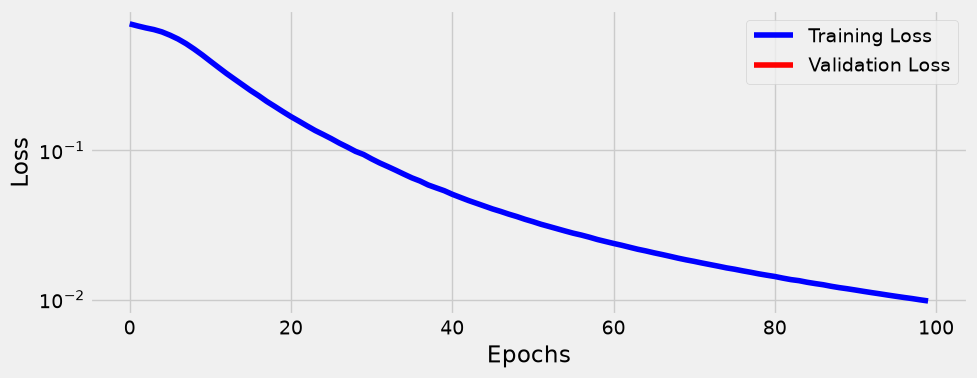

In [580]:
#程序8-22-4: 可视化损失
fig = sbs_packed.plot_losses()

In [581]:
#程序8-22-5: 计算准确率
StepByStep.loader_apply(train_var_loader, sbs_packed.correct)

tensor([[66, 66],
        [62, 62]])

> 实现打包模型时要注意解包和找最后一个元素的逻辑

# 一维卷积

**Q**: 回顾
- 移动平均
- 移动加权和

**Q**: 回答问题
- 一维卷积的计算逻辑是什么样的？
- 什么是步幅？

![](images/conv1_ma.png)

In [582]:
# 引入
import torch.nn.functional as F

In [583]:
# 程序8-23: 一维卷积（移动窗口）示例
temperatures = np.array([5, 11, 15, 6, 5, 3, 3, 0, 0, 3, 4, 2, 1])

size = 5
weight = torch.ones(size) * 0.2

# 注意张量的结构仍然是三维的(默认步长为1)
F.conv1d(torch.as_tensor(temperatures).float().view(1, 1, -1), 
         weight=weight.view(1, 1, -1))

tensor([[[8.4000, 8.0000, 6.4000, 3.4000, 2.2000, 1.8000, 2.0000, 1.8000,
          2.0000]]])

> 一维卷积就是移动窗口加权求和，在实现时注意张量的形状

## 形状

**Q**: 回顾
- NCHW是什么意思？

**Q**：回答问题
- NCL是什么意思？

**Q**: 结合表格
- 不同场景会对应什么格式？

| 形状格式 | 含义 | 适用场景 | 备注 |
|----------|------|----------|------|
| **NLF** | (Batch, Length, Feature) | 批量优化 | PyTorch 中 `batch_first=True` 的默认格式，便于批量操作和 GPU 并行 |
| **LNF** | (Length, Batch, Feature) | RNN 友好 | PyTorch RNN 的默认输入格式（`batch_first=False`），时间步优先便于循环展开 |
| **NFL** | (Batch, Feature, Length) | 序列最后 | 一维卷积 `Conv1d` 的默认值，通道维度(F)在长度维度(L)之前 |


In [584]:
# 程序8-24: permute的使用
seqs = torch.as_tensor(points).float() # N, L, F
seqs_length_last = seqs.permute(0, 2, 1) 
seqs_length_last.shape # N, F/C, L

torch.Size([128, 2, 4])

> 序列最后是一维卷积的默认格式，RNN友好是序列优先，还有一个批量优化

## 多特征或通道

**Q**: 回答问题
- 多通道下，一维矩阵的计算方式？
- 如何计算输出形状？（如何舍入）

![](images/conv1d.png)

$$
\Large
l_i * f = \frac{(l_i + 2p) - f}{s}+1
$$

In [585]:
# 程序8-25-1: 多通道一维卷积的使用

torch.manual_seed(17)
conv_seq = nn.Conv1d(in_channels=2, out_channels=1, kernel_size=2, bias=False)
conv_seq.weight, conv_seq.weight.shape

(Parameter containing:
 tensor([[[-0.0658,  0.0351],
          [ 0.3302, -0.3761]]], requires_grad=True),
 torch.Size([1, 2, 2]))

In [586]:
# 程序8-25-2: 输出结果

conv_seq(seqs_length_last[0:1])

tensor([[[ 0.6241, -0.0274, -0.6412]]], grad_fn=<ConvolutionBackward0>)

> 多通道的一维卷积计算方法和一般卷积大同小异，计算形状时要向下舍入

## 膨胀

**Q**: 回答问题
- 膨胀的计算逻辑是什么？
- 形状的计算公式是？（如何舍入？）

![](images/conv1d_dilated.png)

$$
\Large
l_i * f = \frac{(l_i + 2p) - d(f - 1) - 1}{s}+1
$$

In [587]:
# 程序8-26-1: 多通道一维卷积的使用

torch.manual_seed(17)
conv_dilated = nn.Conv1d(in_channels=2, out_channels=1, kernel_size=2, dilation=2, bias=False)
conv_dilated.weight, conv_dilated.weight.shape

(Parameter containing:
 tensor([[[-0.0658,  0.0351],
          [ 0.3302, -0.3761]]], requires_grad=True),
 torch.Size([1, 2, 2]))

In [588]:
# 程序8-26-2: 输出结果
conv_dilated(seqs_length_last[0:1])

tensor([[[ 0.5793, -0.7376]]], grad_fn=<ConvolutionBackward0>)

> 膨胀的一维卷积计算方法是将卷积核裂开一段距离，计算形状时要向下舍入

## 数据准备

In [589]:
# 程序8-27-1: 数据准备，只是修改成NFL形状

train_data = TensorDataset(torch.as_tensor(points).float().permute(0, 2, 1), 
                           torch.as_tensor(directions).view(-1, 1).float())
test_data = TensorDataset(torch.as_tensor(test_points).float().permute(0, 2, 1), 
                          torch.as_tensor(test_directions).view(-1, 1).float())

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
test_loader = DataLoader(test_data, batch_size=16)

## 模型配置和训练

**Q**：回顾
- 一个卷积核有什么组成？

In [590]:
# 程序8-27-2: 模型配置
torch.manual_seed(21)
model = nn.Sequential()
model.add_module('conv1d', nn.Conv1d(2, 1, kernel_size=2))
model.add_module('relu', nn.ReLU())
model.add_module('flatten', nn.Flatten())
model.add_module('output', nn.Linear(3, 1))
loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [591]:
# 程序8-27-3: 模型训练
sbs_conv1 = StepByStep(model, loss, optimizer)
sbs_conv1.set_loaders(train_loader, test_loader)
sbs_conv1.train(100)

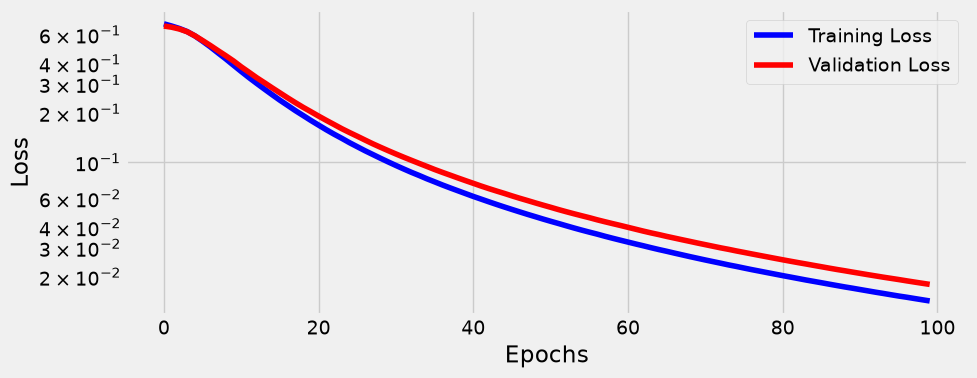

In [592]:
# 程序8-27-4: 可视化损失
fig = sbs_conv1.plot_losses()

In [593]:
# 程序8-27-5: 计算准确率
StepByStep.loader_apply(test_loader, sbs_conv1.correct)

tensor([[53, 53],
        [75, 75]])

## 可视化模型

**Q**：回答问题
- 说明这个模型能成功的原理？

In [594]:
model.conv1d.state_dict()

OrderedDict([('weight',
              tensor([[[-0.2017,  2.3691],
                       [-2.4136, -0.1616]]], device='cuda:0')),
             ('bias', tensor([-0.5586], device='cuda:0'))])

![](images/conv1d_edges.png)

$$
\Large
\text{edge feature} = - 0.22\ x_0^{\text{1st}} - 2.38\ x_1^{\text{1st}} + 2.33\ x_0^{\text{2nd}} - 0.18\ x_1^{\text{2nd}} - 0.5457
$$

$$
\Large
\overline{\text{AD}}\ or\ \overline{\text{DC}} \implies x_1^{\text{1st}} \approx -1\ \text{and}\ x_0^{\text{2nd}} \approx 1 \implies \text{edge feature} > 0
$$

> 一维卷积模型能出色的完成正方形问题的处理，只因卷积核在平移时计算的是边特征，边特征大于0两条边就是相邻的，模型根据两个相同方向的边做出判断，看图可知让边特征为正的方式可找出规律

> 另外，任何依赖单边的模型都可能因特定边缺失而失败，所以最少使用两条边做分类

# 总结（TODO)

## 定长数据集

In [ ]:
points, directions = generate_sequences(n=128, seed=13)
train_data = TensorDataset(torch.as_tensor(points).float(), 
                           torch.as_tensor(directions).view(-1, 1).float())
train_loader = DataLoader(train_data, batch_size=16, shuffle=True)

## 变长数据集

In [ ]:
var_points, var_directions = generate_sequences(variable_len=True)

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, x, y):
        self.x = [torch.as_tensor(s).float() for s in x]
        self.y = torch.as_tensor(y).float().view(-1, 1)
        
    def __getitem__(self, index):
        return (self.x[index], self.y[index])

    def __len__(self):
        return len(self.x)
    
train_var_data = CustomDataset(var_points, var_directions)

In [ ]:
def pack_collate(batch):
    X = [item[0] for item in batch]
    y = [item[1] for item in batch]
    X_pack = rnn_utils.pack_sequence(X, enforce_sorted=False)

    return X_pack, torch.as_tensor(y).view(-1, 1)

train_var_loader = DataLoader(train_var_data, batch_size=16, shuffle=True, collate_fn=pack_collate)

## 通用模型类

In [ ]:
class SquareModelOne(nn.Module):
    def __init__(self, n_features, hidden_dim, n_outputs, rnn_layer=nn.LSTM, **kwargs):
        super(SquareModelOne, self).__init__()
        self.hidden_dim = hidden_dim
        self.n_features = n_features
        self.n_outputs = n_outputs
        self.hidden = None
        self.cell = None
        # 通过rnn_layer参数灵活指定RNN类型（LSTM/GRU/RNN），batch_first=True统一使用NLF格式
        self.basic_rnn = rnn_layer(self.n_features, self.hidden_dim, batch_first=True, **kwargs)
        # 自动计算输出维度：双向时 ×2，单向时 ×1
        output_dim = (self.basic_rnn.bidirectional + 1) * self.hidden_dim
        # 分类器：将RNN隐藏状态映射到输出logits
        self.classifier = nn.Linear(output_dim, self.n_outputs)

    def forward(self, X):
        # 检测输入类型：同时兼容填充张量和打包序列两种格式
        is_packed = isinstance(X, nn.utils.rnn.PackedSequence)
        # 若X是打包序列，无需permute——PackedSequence内部已是时间步优先

        rnn_out, self.hidden = self.basic_rnn(X)
        # 若为LSTM，hidden是(h, c)元组，需分别保存
        if isinstance(self.basic_rnn, nn.LSTM):
            self.hidden, self.cell = self.hidden

        if is_packed:
            # 解包输出：PackedSequence → 填充张量(N, L, H*D)，D=方向数
            batch_first_output, seq_sizes = rnn_utils.pad_packed_sequence(rnn_out, batch_first=True)
            seq_slice = torch.arange(seq_sizes.size(0))
        else:
            # 填充张量路径：无需解包，直接用:-1取最后时间步
            batch_first_output = rnn_out
            seq_sizes = 0  # 使seq_sizes-1 = -1，即取最后一个时间步
            seq_slice = slice(None, None, None)  # 等价于':'

        # 提取每个序列的最后一个有效输出，形状(N, H*D)
        last_output = batch_first_output[seq_slice, seq_sizes-1]

        # 分类器输出logits，形状(N, n_outputs)
        out = self.classifier(last_output)

        # 展平为(N, n_outputs)返回
        return out.view(-1, self.n_outputs)

## 模型配置和训练

In [ ]:
torch.manual_seed(21)
model = SquareModelOne(n_features=2, hidden_dim=2, n_outputs=1,
                       rnn_layer=nn.LSTM, num_layers=1, bidirectional=True)
loss = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
sbs_one = StepByStep(model, loss, optimizer)
#sbs_one.set_loaders(train_loader)
sbs_one.set_loaders(train_var_loader)
sbs_one.train(100)

In [ ]:
#StepByStep.loader_apply(train_loader, sbs_one.correct)
StepByStep.loader_apply(train_var_loader, sbs_one.correct)